## PIPELINE

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Union

# Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score, 
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# PanelSplit
from panelsplit.cross_validation import PanelSplit
from panelsplit.plot import plot_splits
from panelsplit.application import cross_val_fit_predict

# Python built-in random module for reproducibility
import random         
np.random.seed(20269999)               # fix NumPy global random state
random.seed(20269999)                  # fix Python built-in random state
# Note: sklearn RF uses its own random_state=42 parameter set in the model directly

### 1. LOAD DATA AND PREPROCESS 

#### EPIDEMIES DATA

This is the core dataset to construct our target variable. It contains all the information related to epidemics from 2000 to 2025.

In [2]:
# Load the data
df_target = pd.read_excel('data/emdat_target_variable.xlsx')

print(df_target.columns)
df_target.head()

Index(['DisNo.', 'Historic', 'Classification Key', 'Disaster Group',
       'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype',
       'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region',
       'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal',
       'Declaration', 'AID Contribution ('000 US$)', 'Magnitude',
       'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year',
       'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
       'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless',
       'Total Affected', 'Reconstruction Costs ('000 US$)',
       'Reconstruction Costs, Adjusted ('000 US$)',
       'Insured Damage ('000 US$)', 'Insured Damage, Adjusted ('000 US$)',
       'Total Damage ('000 US$)', 'Total Damage, Adjusted ('000 US$)', 'CPI',
       'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update'],
      dtype='str')


,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2001-0551-MOZ,No,nat-bio-epi-bac,Natural,Biological,Epidemic,Bacterial disease,NaN,Cholera,MOZ,...,NaN,NaN,NaN,NaN,NaN,54.999385,NaN,NaN,2003-07-01,2023-09-25
1,2006-0726-PRK,No,nat-bio-epi-vir,Natural,Biological,Epidemic,Viral disease,NaN,NaN,PRK,...,NaN,NaN,NaN,NaN,NaN,62.617195,NaN,NaN,2007-03-28,2023-09-25
2,2000-0460-THA,No,nat-bio-epi-bac,Natural,Biological,Epidemic,Bacterial disease,NaN,NaN,THA,...,NaN,NaN,NaN,NaN,NaN,53.487737,NaN,NaN,2003-07-01,2023-09-25
3,2022-0643-HTI,No,nat-bio-epi-bac,Natural,Biological,Epidemic,Bacterial disease,GLIDE:EP-2022-000325,Cholera,HTI,...,NaN,NaN,NaN,NaN,NaN,90.902697,NaN,NaN,2022-10-10,2023-09-26
4,2022-0652-UGA,No,nat-bio-epi-vir,Natural,Biological,Epidemic,Viral disease,GLIDE:EP-2022-000315,Ebola,UGA,...,NaN,NaN,NaN,NaN,NaN,90.902697,NaN,NaN,2022-10-11,2023-09-26


In [3]:
df_target["Disaster Type"].value_counts()

Disaster Type
Epidemic       893
Infestation     29
Name: count, dtype: int64

We only want to keep the ones where `Disaster Type` == Epidemic, as we are trying to predict a new epidemy.

In [4]:
df_target = df_target[df_target["Disaster Type"]=="Epidemic"]

Now we are interested in agregating the data by country and month. To characterize the country we are going to use the ISO code.

In [5]:
df_target["Start Month"].head()

0     8.0
1    11.0
2     1.0
3    10.0
4     9.0
Name: Start Month, dtype: float64

In [6]:
df_target["Start Year"].head()

0    2001
1    2006
2    2000
3    2022
4    2022
Name: Start Year, dtype: int64

We need to creat the variable `month` from the two columns `Start Month` and `Start Year`. First we are dropping all the rows that doesen't have the `Start Month` or `Start Year`, because those are the main things that we need to have.

In [7]:
nan_summary = df_target[['Start Month', 'Start Year']].isna().sum()

print("Total Missing Values per Column:")
print(nan_summary)

Total Missing Values per Column:
Start Month    24
Start Year      0
dtype: int64


In [8]:
df_target = df_target.dropna(subset=['Start Month', 'Start Year'])

Now let's create the month variable:

In [9]:
df_target['month'] = pd.to_datetime({
    'year': df_target['Start Year'],
    'month': df_target['Start Month'],
    'day': 1
})

# Verify the result
print(df_target[['Start Year', 'Start Month', 'month']].head())

   Start Year  Start Month      month
0        2001          8.0 2001-08-01
1        2006         11.0 2006-11-01
2        2000          1.0 2000-01-01
3        2022         10.0 2022-10-01
4        2022          9.0 2022-09-01


In [10]:
print("Oldest date:", df_target['month'].min())
print("Latest date:", df_target['month'].max())

Oldest date: 2000-01-01 00:00:00
Latest date: 2025-12-01 00:00:00


The last thing that we have to do is check that there are no missing values in `ISO` column, as is the other one that we are going to use to aggregate the data.

In [11]:
print(df_target['ISO'].isna().sum())

0


In [12]:
df_target["ISO"].unique()

<StringArray>
['MOZ', 'PRK', 'THA', 'HTI', 'UGA', 'CAF', 'COD', 'FJI', 'TON', 'SDN',
 ...
 'DZA', 'FSM', 'MHL', 'CAN', 'GBR', 'NCL', 'MRT', 'MUS', 'COK', 'MEX']
Length: 131, dtype: str

Finally we set the multi-index (Entity (`ISO`) and Time (`month`)):

In [13]:
df_target = df_target.set_index(['ISO', 'month']).sort_index()

In order to facilitate the study, we are going to create a dataframe only containing the presence or absence of epidemic's outbreak. This new DataFrame expands our data into a balanced panel where every country (ISO) is mapped against every available time period (month). The final dataset uses a MultiIndex ['ISO', 'month'] and a single binary column, epidemy, where a 1 indicates an epidemic outbreak and a 0 indicates no recorded activity for that specific country and period, meaning no epidemic outbreak registered.

In [14]:
df_target['epidemy'] = 1
df_collapsed = df_target.groupby(['ISO', 'month'])[['epidemy']].max()

# Find the absolute start and end dates across your entire dataset
min_date = df_collapsed.index.get_level_values('month').min()
max_date = df_collapsed.index.get_level_values('month').max()

# Generate EVERY single month in between (freq='MS' means Month Start)
perfect_month_range = pd.date_range(start=min_date, end=max_date, freq='MS')

# Get all unique countries
all_isos = df_collapsed.index.get_level_values('ISO').unique()

# Build the perfect MultiIndex grid combining ALL countries with EVERY single consecutive month
full_index = pd.MultiIndex.from_product(
    [all_isos, perfect_month_range], 
    names=['ISO', 'month']
)

# Reindex your data into this perfect grid. 
epidemy = df_collapsed.reindex(full_index, fill_value=0).sort_index()

# Verification
print(f"Generated a perfect continuous timeline of {len(perfect_month_range)} months per country.")
print(epidemy.head(24))
print("\nValue counts:")
print(epidemy['epidemy'].value_counts())


Generated a perfect continuous timeline of 312 months per country.
                epidemy
ISO month              
AFG 2000-01-01        1
    2000-02-01        0
    2000-03-01        0
    2000-04-01        0
    2000-05-01        1
    2000-06-01        0
    2000-07-01        0
    2000-08-01        1
    2000-09-01        1
    2000-10-01        0
    2000-11-01        0
    2000-12-01        0
    2001-01-01        0
    2001-02-01        0
    2001-03-01        0
    2001-04-01        0
    2001-05-01        0
    2001-06-01        1
    2001-07-01        0
    2001-08-01        0
    2001-09-01        0
    2001-10-01        0
    2001-11-01        0
    2001-12-01        1

Value counts:
epidemy
0    40066
1      806
Name: count, dtype: int64


In [15]:
epidemy.to_csv("data/epidemy.csv", index=True)

#### FEATURE VARAIBLES

The second dataset that we need is one containing all the variables assocciated with health that will help us predict an epidemology. In this case we are using data from Health World Bank, divided in 8 files containing information from 1960 to 2024. 

In [16]:
folder_path = 'data/health_world_bank/'
files = []

# Find all CSV files inside the data folder
for filename in os.listdir(folder_path):
    if filename.endswith(".csv"):
        files.append(filename)

# Process and merge the datasets
for idx, file in enumerate(files):
    df = pd.read_csv(os.path.join(folder_path, file))
    df = df.dropna(subset=['Country Code'])
    df = df.set_index(['Series Name', 'Country Code'])
    df = df.drop(['Series Code', 'Country Name'], axis=1)
    
    if idx == 0:
        regressors = df.copy()
    else:
        regressors = regressors.join(df)

print(f"Total files processed: {len(files)}")
regressors

Total files processed: 8


1960 [YR1960]  \
Series Name                                        Country Code                 
Cause of death, by communicable diseases and ma... AFG                     ..   
                                                   AFE                     ..   
                                                   AFW                     ..   
                                                   ALB                     ..   
                                                   DZA                     ..   
...                                                                       ...   
Specialist surgical workforce (per 100,000 popu... PSE                     ..   
                                                   WLD                     ..   
                                                   YEM                     ..   
                                                   ZMB                     ..   
                                                   ZWE                     ..   

                                                                1961 [YR1961]  \
Series Name                                        Country Code                 
Cause of death, by communicable diseases and ma... AFG                     ..   
                                                   AFE                     ..   
                                                   AFW                     ..   
                                                   ALB                     ..   
                                                   DZA                     ..   
...                                                                       ...   
Specialist surgical workforce (per 100,000 popu... PSE                     ..   
                                                   WLD                     ..   
                                                   YEM                     ..   
                                                   ZMB                     ..   
                                                   ZWE                     ..   

                                                                1962 [YR1962]  \
Series Name                                        Country Code                 
Cause of death, by communicable diseases and ma... AFG                     ..   
                                                   AFE                     ..   
                                                   AFW                     ..   
                                                   ALB                     ..   
                                                   DZA                     ..   
...                                                                       ...   
Specialist surgical workforce (per 100,000 popu... PSE                     ..   
                                                   WLD                     ..   
                                                   YEM                     ..   
                                                   ZMB                     ..   
                                                   ZWE                     ..   

                                                                1963 [YR1963]  \
Series Name                                        Country Code                 
Cause of death, by communicable diseases and ma... AFG                     ..   
                                                   AFE                     ..   
                                                   AFW                     ..   
                                                   ALB                     ..   
                                                   DZA                     ..   
...                                                                       ...   
Specialist surgical workforce (per 100,000 popu... PSE                     ..   
                                                   WLD                     ..   
                                                   YEM                     ..   
           

As we can see, this data comes in a weird format, so we are going to preprocess it to obtain the desired format: each row should be a country x month, and all the series should be columns.

In [17]:
regressors.columns = regressors.columns.str.extract(r'(\d{4})', expand=False)
regressors.columns.name = 'Year'

reg_final = (regressors
             .stack()
             .unstack('Series Name')
             .reset_index()
            )

reg_final.columns.name = None

reg_final.sample(10)

,Country Code,Year,ARI treatment (% of children under 5 taken to a health provider),Capital health expenditure (% of GDP),"Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)","Cause of death, by injury (% of total)","Cause of death, by non-communicable diseases (% of total)","Cause of death, by other COVID-19 pandemic-related outcomes (% of total)",Children with fever receiving antimalarial drugs (% of children under age 5 with fever),"Community health workers (per 1,000 people)",...,"People with basic handwashing facilities including soap and water, rural (% of rural population)","People with basic handwashing facilities including soap and water, urban (% of urban population)",Proportion of population pushed or further pushed below the $3.65 ($ 2017 PPP) poverty line by out-of-pocket health care expenditure (%),Proportion of population spending more than 25% of household consumption or income on out-of-pocket health care expenditure (%),"Specialist surgical workforce (per 100,000 population)","Tuberculosis case detection rate (%, all forms)","Tuberculosis death rate (per 100,000 people)",Tuberculosis treatment success rate (% of new cases),UHC service coverage index,Use of insecticide-treated bed nets (% of under-5 population)
8024,KHM,1995,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
3688,DJI,2003,..,..,..,..,..,..,..,..,...,..,..,..,..,..,22,663,73,..,..
3763,DMA,2013,..,0.248245301115242,..,..,..,..,..,..,...,..,..,..,..,..,100,..,100,..,..
7309,IRN,1995,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
4094,EAR,2019,..,..,22.19629046798,9.51414523877341,68.2895642932466,0,16.4756051110591,..,...,63.2948287853348,82.2799285717621,..,..,..,..,..,..,..,..
12650,PRT,1976,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
8231,KOR,1977,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
10854,MRT,2019,..,0.109017847354703,44.2199742587814,9.29140292022641,46.4886228209924,0,..,..,...,26.6521641660211,61.989100773063,..,..,..,63,15,81,36,..
4293,ECU,1963,..,..,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
5830,GRC,2000,..,..,3.89752324536745,3.81970761253718,92.2827691420954,0,..,..,...,..,..,..,..,..,68,0.91,..,69,..


To handle missing values without distorting country profiles, we group the data by country and propagate the last available historical value forward in time. Any remaining columns with absolutely no historical data for a specific country are safely filled using the mean of the other countries at that month.

Note that we can't do Backward Fill because that will introduce data leakage (seeing data from the futur in the present).

First note that in this dataset Nan are introduced as `..`, so the first thing is replace these fore real NaN.

In [18]:
# Replace '..' with actual NaN values 
reg = reg_final.replace('..', np.nan)
reg = reg.sort_values(by=['Country Code', 'Year']).reset_index(drop=True)

for col in reg.columns:
    if col not in ['Country Code', 'Year']:
        reg[col] = pd.to_numeric(reg[col], errors='coerce')

# Forward-fill within each country to maintain trends, but only for numeric columns
cols_numericas = reg.select_dtypes(include=[np.number]).columns
cols_to_trend = cols_numericas.drop(['Year'], errors='ignore')
reg[cols_to_trend] = reg.groupby('Country Code')[cols_to_trend].ffill()

# Put the median of the other countries for the same year as a last resort for any remaining NaNs that couldn't be filled by trends
reg[cols_to_trend] = reg.groupby('Year')[cols_to_trend].transform(lambda x: x.fillna(x.median()))

We are going to check now the state of the remaining missing values:

In [19]:
reg['Year'] = reg['Year'].astype(int)

# Find the first year with at least ONE valid value per column
first_valid_years = {}

for col in cols_to_trend:
    # Filter rows where the column is not NaN, then find the minimum year
    non_nan_years = reg[reg[col].notna()]['Year']
    if not non_nan_years.empty:
        first_valid_years[col] = non_nan_years.min()
    else:
        first_valid_years[col] = None

print("--- First Year with Data per Column ---")
for col, year in first_valid_years.items():
    print(f"{col}: {year}")


# Find the year from which the column is COMPLETELY FULL (no NaNs onwards)
fully_filled_from_years = {}

# We group by Year to see if there is ANY NaN globally in that year for each column
nan_by_year = reg.groupby('Year')[cols_to_trend].apply(lambda x: x.isna().any())

for col in cols_to_trend:
    # Get all years where this column still has at least one NaN
    years_with_nans = nan_by_year.index[nan_by_year[col]]
    
    if len(years_with_nans) == 0:
        # If there are no NaNs anywhere, it's fully filled from the very first year available
        fully_filled_from_years[col] = reg['Year'].min()
    else:
        # The year from which it is completely full is the year AFTER the last NaN ever found
        last_nan_year = years_with_nans.max()
        next_year = last_nan_year + 1
        
        # Check if the next year actually exists in our dataset
        if next_year <= reg['Year'].max():
            fully_filled_from_years[col] = next_year
        else:
            fully_filled_from_years[col] = "Never fully filled (NaNs present until the last year)"

print("\n--- Year from which Column is Completely Full (No NaNs onwards) ---")
for col, year in fully_filled_from_years.items():
    print(f"{col}: {year}")

--- First Year with Data per Column ---
ARI treatment (% of children under 5 taken to a health provider): 2000
Capital health expenditure (% of GDP): 2000
Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total): 2000
Cause of death, by injury (% of total): 2000
Cause of death, by non-communicable diseases (% of total): 2000
Cause of death, by other COVID-19 pandemic-related outcomes (% of total): 2000
Children with fever receiving antimalarial drugs (% of children under age 5 with fever): 1998
Community health workers (per 1,000 people): 1990
Current health expenditure (% of GDP): 2000
Current health expenditure per capita (current US$): 2000
Current health expenditure per capita, PPP (current international $): 2000
Diarrhea treatment (% of children under 5 receiving oral rehydration and continued feeding): 1986
Diarrhea treatment (% of children under 5 who received ORS packet): 1985
Domestic general government health expenditure (% of GDP)

We are going to keep only the columns that have data since 2000, because our target variable will be available since 2000.

In [20]:
# 1. Filter the dataframe to look only at the year 2000
reg['Year'] = reg['Year'].astype(int)
df_2000 = reg[reg['Year'] == 2000]

# 2. Identify which columns have any NaN values in the year 2000
# We only check the columns that are inside 'cols_to_trend'
columns_with_nans_in_2000 = df_2000[cols_to_trend].columns[df_2000[cols_to_trend].isna().any()].tolist()

# 3. Drop these columns from your main DataFrame
reg_filtered = reg.drop(columns=columns_with_nans_in_2000)

# 4. Update your list of numeric columns for future steps
cols_to_trend = [col for col in cols_to_trend if col not in columns_with_nans_in_2000]

# Print the results to verify
print(f"Columns dropped because they had NaNs in 2000: {len(columns_with_nans_in_2000)}")
print(f"Columns remaining: {len(cols_to_trend)}")
print("Dropped columns list:", columns_with_nans_in_2000)

Columns dropped because they had NaNs in 2000: 5
Columns remaining: 61
Dropped columns list: ['Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)', 'Mortality rate attributed to household and ambient air pollution (per 100,000 population)', 'Mortality rate attributed to unsafe water, unsafe sanitation and lack of hygiene (per 100,000 population)', 'Number of surgical procedures (per 100,000 population)', 'Specialist surgical workforce (per 100,000 population)']


Now we are going to delete the rows corresponding to years before 1990.

In [21]:
# 1. Ensure 'Year' is an integer for proper numerical comparison
reg_filtered['Year'] = reg_filtered['Year'].astype(int)

# 2. Keep only the rows from 2000 onwards using your ALREADY filtered dataframe
reg_filtered = reg_filtered[reg_filtered['Year'] >= 2000]

# Print the final validation
print(f"Data now ranges from Year: {reg_filtered['Year'].min()} to {reg_filtered['Year'].max()}")
print(f"Total rows remaining in the dataset: {len(reg_filtered)}")

Data now ranges from Year: 2000 to 2024
Total rows remaining in the dataset: 6650


In [22]:
reg_filtered.head()

,Country Code,Year,ARI treatment (% of children under 5 taken to a health provider),Capital health expenditure (% of GDP),"Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)","Cause of death, by injury (% of total)","Cause of death, by non-communicable diseases (% of total)","Cause of death, by other COVID-19 pandemic-related outcomes (% of total)",Children with fever receiving antimalarial drugs (% of children under age 5 with fever),"Community health workers (per 1,000 people)",...,People with basic handwashing facilities including soap and water (% of population),"People with basic handwashing facilities including soap and water, rural (% of rural population)","People with basic handwashing facilities including soap and water, urban (% of urban population)",Proportion of population pushed or further pushed below the $3.65 ($ 2017 PPP) poverty line by out-of-pocket health care expenditure (%),Proportion of population spending more than 25% of household consumption or income on out-of-pocket health care expenditure (%),"Tuberculosis case detection rate (%, all forms)","Tuberculosis death rate (per 100,000 people)",Tuberculosis treatment success rate (% of new cases),UHC service coverage index,Use of insecticide-treated bed nets (% of under-5 population)
40,ABW,2000,50.0,0.191211,20.639072,7.363803,67.121559,0.0,35.491079,0.430,...,23.709019,3.785651,32.750212,12.190,1.150,46.0,11.0,77.5,47.0,2.0
41,ABW,2001,47.5,0.212884,20.639072,7.363803,67.121559,0.0,36.000000,0.197,...,23.780605,4.377467,32.604566,12.090,1.135,47.5,11.0,76.0,47.0,2.0
42,ABW,2002,49.5,0.249289,20.639072,7.363803,67.121559,0.0,35.745540,0.197,...,23.852720,5.055387,32.604566,13.400,1.155,50.0,12.0,78.0,47.0,2.0
43,ABW,2003,49.0,0.200781,20.639072,7.363803,67.121559,0.0,34.300000,0.417,...,23.777391,5.733307,32.604566,13.425,1.200,52.0,11.0,79.5,47.0,2.0
44,ABW,2004,50.5,0.169674,20.639072,7.363803,67.121559,0.0,34.250000,0.204,...,15.597712,7.574972,32.236933,11.435,1.135,53.0,12.0,80.5,47.0,2.3


In [23]:
reg_filtered.isna().sum()

Country Code                                                                                             0
Year                                                                                                     0
ARI treatment (% of children under 5 taken to a health provider)                                         0
Capital health expenditure (% of GDP)                                                                    0
Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)    0
                                                                                                        ..
Tuberculosis case detection rate (%, all forms)                                                          0
Tuberculosis death rate (per 100,000 people)                                                             0
Tuberculosis treatment success rate (% of new cases)                                                     0
UHC service coverage index           

Next we have to face another problem, that is that we want the data agreggated by month, but we have it by year in the regressors. That's what we are going to face now.

To strictly avoid data leakage, all annual indicators and their corresponding yearly trends are shifted one year forward for each country before generating the monthly data. As a result, the monthly values for a given year are constructed exclusively using information that would have been available at the beginning of that year.

The interpolation process starts from the previous year’s observed annual value and progressively applies a monthly trend derived from historical year-over-year changes. This creates a smooth intra-year evolution while ensuring that no future annual statistics are used during feature generation. Although this approach introduces a discontinuous adjustment at the transition between years, it is considered appropriate because these macroeconomic and structural indicators tend to evolve gradually and remain relatively stable over time. Most importantly, this design mathematically guarantees a leakage-free temporal construction of the regressors.

In [24]:
# Ensure that the Year column is stored as an integer and sort the dataframe
reg_filtered['Year'] = reg_filtered['Year'].astype(int)
reg_filtered = reg_filtered.sort_values(['Country Code', 'Year']).reset_index(drop=True)

# Compute the year-over-year variation for each indicator separately by country
group_diff = reg_filtered.groupby('Country Code')[cols_to_trend].diff().fillna(0)

# Convert yearly variation into an approximate monthly trend (uniform distribution across 12 months)
trends_df = (group_diff / 12).rename(columns=lambda x: x + '_trend')

# Combine original annual indicators with their corresponding monthly trend estimates
reg_annual_combined = pd.concat([reg_filtered, trends_df], axis=1)

# FIX FOR THE YEAR 2025: Create an annual skeleton that includes the next forecast year
all_countries = reg_filtered['Country Code'].unique()
current_years = list(reg_filtered['Year'].unique())
next_year = max(current_years) + 1  # This will dynamically add 2025 if max is 2024
current_years.append(next_year)

annual_skeleton = pd.MultiIndex.from_product(
    [all_countries, current_years],
    names=['Country Code', 'Year']
).to_frame().reset_index(drop=True)

# Merge back so every country now physically has an empty row allocated for 2025
reg_annual_combined = pd.merge(annual_skeleton, reg_annual_combined, on=['Country Code', 'Year'], how='left')

# Prevent data leakage: Shift indicator values and estimated trends 1 year forward for each country
# Now, the real 2024 values will safely slide down into the newly created 2025 rows.
cols_to_shift = list(cols_to_trend) + [c for c in reg_annual_combined.columns if c.endswith('_trend')]
reg_annual_combined[cols_to_shift] = reg_annual_combined.groupby('Country Code')[cols_to_shift].shift(1)
reg_annual_combined = reg_annual_combined.fillna(0)

# Generate all possible combinations of country, year, and month (1 to 12)
all_countries = reg_annual_combined['Country Code'].unique()
all_years = reg_annual_combined['Year'].unique()  # This now successfully includes 2025
all_months = range(1, 13)

monthly_skeleton = pd.MultiIndex.from_product(
    [all_countries, all_years, all_months],
    names=['Country Code', 'Year', 'month']
).to_frame().reset_index(drop=True)

# Merge the annual structure into the expanded monthly calendar skeleton
reg_monthly = pd.merge(monthly_skeleton, reg_annual_combined, on=['Country Code', 'Year'], how='left')

# Apply monthly linear interpolation
# Formula: monthly_value = shifted_annual_value + (monthly_trend * months_elapsed)
for col in cols_to_trend:
    reg_monthly[col] = reg_monthly[col] + (reg_monthly[col + '_trend'] * (reg_monthly['month'] - 1))

# Clean up auxiliary trend columns
trend_cols = [c for c in reg_monthly.columns if c.endswith('_trend')]
reg_monthly = reg_monthly.drop(columns=trend_cols)

# Delete the first year of data because it should be Nan
first_year = reg_monthly['Year'].min()
reg_monthly = reg_monthly[reg_monthly['Year'] > first_year].reset_index(drop=True)

Finally putting the same format as the epidemics dataframe.

In [25]:
# Create the month column as a datetime object representing the first day of each month. 
# Also we delete the Year column and rename 'Country Code' to 'ISO' for consistency with the target variable.
date_string = reg_monthly['Year'].astype(str) + '-' + reg_monthly['month'].astype(str) + '-01'
reg_monthly['month'] = pd.to_datetime(date_string)
reg_monthly = reg_monthly.drop(columns=['Year']).rename(columns={'Country Code': 'ISO'})

regressors = reg_monthly.set_index(['ISO', 'month']).sort_index()

In [26]:
print("Oldest date:", regressors.index.get_level_values('month').min())
print("Latest date:", regressors.index.get_level_values('month').max())

Oldest date: 2001-01-01 00:00:00
Latest date: 2025-12-01 00:00:00


In [27]:
regressors.index.get_level_values('ISO').unique()

Index(['ABW', 'AFE', 'AFG', 'AFW', 'AGO', 'ALB', 'AND', 'ARB', 'ARE', 'ARG',
       ...
       'VIR', 'VNM', 'VUT', 'WLD', 'WSM', 'XKX', 'YEM', 'ZAF', 'ZMB', 'ZWE'],
      dtype='str', name='ISO', length=266)

In [28]:
regressors.head()

ARI treatment (% of children under 5 taken to a health provider)  \
ISO month                                                                          
ABW 2001-01-01                                               50.0                  
    2001-02-01                                               50.0                  
    2001-03-01                                               50.0                  
    2001-04-01                                               50.0                  
    2001-05-01                                               50.0                  

                Capital health expenditure (% of GDP)  \
ISO month                                               
ABW 2001-01-01                               0.191211   
    2001-02-01                               0.191211   
    2001-03-01                               0.191211   
    2001-04-01                               0.191211   
    2001-05-01                               0.191211   

                Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)  \
ISO month                                                                                                               
ABW 2001-01-01                                          20.639072                                                       
    2001-02-01                                          20.639072                                                       
    2001-03-01                                          20.639072                                                       
    2001-04-01                                          20.639072                                                       
    2001-05-01                                          20.639072                                                       

                Cause of death, by injury (% of total)  \
ISO month                                                
ABW 2001-01-01                                7.363803   
    2001-02-01                                7.363803   
    2001-03-01                                7.363803   
    2001-04-01                                7.363803   
    2001-05-01                                7.363803   

                Cause of death, by non-communicable diseases (% of total)  \
ISO month                                                                   
ABW 2001-01-01                                          67.121559           
    2001-02-01                                          67.121559           
    2001-03-01                                          67.121559           
    2001-04-01                                          67.121559           
    2001-05-01                                          67.121559           

                Cause of death, by other COVID-19 pandemic-related outcomes (% of total)  \
ISO month                                                                                  
ABW 2001-01-01                                                0.0                          
    2001-02-01                                                0.0                          
    2001-03-01                                                0.0                          
    2001-04-01                                                0.0                          
    2001-05-01                                                0.0                          

                Children with fever receiving antimalarial drugs (% of children under age 5 with fever)  \
ISO month                                                                                                 
ABW 2001-01-01                                          35.491079                                         
    2001-02-01                                          35.491079                                         
    2001-03-01                                          35.491079                                         
    2001-04-01                                      

In [29]:
pd.set_option('display.max_columns', None)
print(regressors.columns)

Index(['ARI treatment (% of children under 5 taken to a health provider)',
       'Capital health expenditure (% of GDP)',
       'Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)',
       'Cause of death, by injury (% of total)',
       'Cause of death, by non-communicable diseases (% of total)',
       'Cause of death, by other COVID-19 pandemic-related outcomes (% of total)',
       'Children with fever receiving antimalarial drugs (% of children under age 5 with fever)',
       'Community health workers (per 1,000 people)',
       'Current health expenditure (% of GDP)',
       'Current health expenditure per capita (current US$)',
       'Current health expenditure per capita, PPP (current international $)',
       'Diarrhea treatment (% of children under 5 receiving oral rehydration and continued feeding)',
       'Diarrhea treatment (% of children under 5 who received ORS packet)',
       'Domestic general government health ex

In [30]:
regressors.to_csv("data/regressors.csv", index=True)

#### TEXT DATA

The text features come from the [conflictforecast.org](https://conflictforecast.org) dataset introduced by Mueller, Rauh & Seimon (2024, *Data & Policy*). A dynamic Latent Dirichlet Allocation (LDA) model with 15 topics was trained on over 6 million newspaper articles (New York Times, Economist, Associated Press, BBC Monitor, LatinNews) from 1989 to present. Each topic is a probability distribution over words; topic shares are computed per country-month and transformed into exponentially weighted moving averages (topic stocks) with decay δ=0.8, giving more weight to recent news.

The 15 topics and their labels are:

| Index | Label | Epidemic Relevance |
|---|---|---|
| 0 | Competition and Sports | None |
| 1 | Health and Education | Medium |
| 2 | Military Conflict | High |
| 3 | Politics | Low |
| 4 | Military Technology | Low |
| 5 | National Development | Low |
| 6 | Political Tensions | Medium |
| 7 | Judiciary and Abuses | Medium |
| 8 | Middle East | Medium |
| 9 | Chinese Politics | Low |
| 10 | Economics | Low |
| **11** | **Diplomacy** | **Highest** |
| 12 | Civilian Life | High |
| 13 | Foreign Policy | Low |
| 14 | Power and Negotiation | Low |

**Why these topics predict epidemic outbreaks:** High scores on topics such as *Diplomacy* (11) and *Military Conflict* (2) concentrate in fragile states under international crisis management (South Sudan, Somalia, DRC, Mali). This reflects three causal channels documented in the epidemiological literature: (1) state fragility breaks down health system capacity; (2) conflict displaces populations into unsanitary conditions; (3) surveillance systems collapse, allowing outbreaks to grow before detection. We therefore use all 15 topic stocks as text-based predictors, alongside derived features (lags, weighted rolling means, rolling standard deviations) to capture both the level and the dynamics of the news signal.

In [31]:
text = pd.read_csv("data/topics.csv", index_col = 0)
text.head()

,isocode,period,stock_topic_0,stock_topic_1,stock_topic_2,stock_topic_3,stock_topic_4,stock_topic_5,stock_topic_6,stock_topic_7,stock_topic_8,stock_topic_9,stock_topic_10,stock_topic_11,stock_topic_12,stock_topic_13,stock_topic_14,tokens,stock_tokens
0,AFG,201001,0.015494,0.028133,0.149828,0.045481,0.070855,0.020226,0.175732,0.052580,0.019800,0.004761,0.022914,0.036579,0.088708,0.060646,0.208263,46266.0,223668.448646
1,AFG,201002,0.015619,0.028952,0.158657,0.041378,0.070569,0.020737,0.164617,0.049715,0.021267,0.004845,0.021915,0.038197,0.093011,0.061759,0.208764,45909.0,224843.758917
2,AFG,201003,0.014970,0.029925,0.153758,0.038190,0.064274,0.021417,0.156693,0.051960,0.025952,0.004937,0.021165,0.039799,0.093782,0.066846,0.216333,43505.0,223380.007134
3,AFG,201004,0.015099,0.031810,0.159417,0.037715,0.063352,0.021735,0.153907,0.052503,0.025788,0.004879,0.021542,0.040595,0.094116,0.066496,0.211046,26844.0,205548.005707
4,AFG,201005,0.014908,0.034902,0.165338,0.034451,0.062574,0.022844,0.148960,0.051360,0.025376,0.004617,0.022203,0.040729,0.098276,0.067144,0.206317,29560.0,193998.404565


As we said the most interessting column here regarding our study is stock_topic_1, bit we are going to keep all of them because maybe they are also usefull. Also we put isocode and month as index:

In [32]:
text['month'] = pd.to_datetime(text['period'].astype(str), format='%Y%m')

# Keep only the necessary columns and rename them to match the desired format
df_filtered = text[[col for col in text.columns if col not in ['tokens', 'stock_tokens']]].copy()
df_filtered = df_filtered.rename(columns={'isocode': 'ISO'})
text = df_filtered.set_index(['ISO', 'month']).sort_index()

text.head()

period  stock_topic_0  stock_topic_1  stock_topic_2  \
ISO month                                                             
AFG 2010-01-01  201001       0.015494       0.028133       0.149828   
    2010-02-01  201002       0.015619       0.028952       0.158657   
    2010-03-01  201003       0.014970       0.029925       0.153758   
    2010-04-01  201004       0.015099       0.031810       0.159417   
    2010-05-01  201005       0.014908       0.034902       0.165338   

                stock_topic_3  stock_topic_4  stock_topic_5  stock_topic_6  \
ISO month                                                                    
AFG 2010-01-01       0.045481       0.070855       0.020226       0.175732   
    2010-02-01       0.041378       0.070569       0.020737       0.164617   
    2010-03-01       0.038190       0.064274       0.021417       0.156693   
    2010-04-01       0.037715       0.063352       0.021735       0.153907   
    2010-05-01       0.034451       0.062574       0.022844       0.148960   

                stock_topic_7  stock_topic_8  stock_topic_9  stock_topic_10  \
ISO month                                                                     
AFG 2010-01-01       0.052580       0.019800       0.004761        0.022914   
    2010-02-01       0.049715       0.021267       0.004845        0.021915   
    2010-03-01       0.051960       0.025952       0.004937        0.021165   
    2010-04-01       0.052503       0.025788       0.004879        0.021542   
    2010-05-01       0.051360       0.025376       0.004617        0.022203   

                stock_topic_11  stock_topic_12  stock_topic_13  stock_topic_14  
ISO month                                                                       
AFG 2010-01-01        0.036579        0.088708        0.060646        0.208263  
    2010-02-01        0.038197        0.093011        0.061759        0.208764  
    2010-03-01        0.039799        0.093782        0.066846        0.216333  
    2010-04-01        0.040595        0.094116        0.066496        0.211046  
    2010-05-01        0.040729        0.098276        0.067144        0.206317

In [33]:
print("Oldest date:", text.index.get_level_values('month').min())
print("Latest date:", text.index.get_level_values('month').max())

Oldest date: 2010-01-01 00:00:00
Latest date: 2024-12-01 00:00:00


In [34]:
text.index.get_level_values('ISO').unique()

Index(['AFG', 'AGO', 'ALB', 'ARE', 'ARG', 'ARM', 'ATG', 'AUS', 'AUT', 'AZE',
       ...
       'URY', 'USA', 'UZB', 'VEN', 'VNM', 'XKX', 'YEM', 'ZAF', 'ZMB', 'ZWE'],
      dtype='str', name='ISO', length=174)

In [35]:
text.to_csv("data/text.csv", index=True)

#### WHO DON 

Data from World Health Organization containing official reports of disease outbreak.

In [36]:
# Load the data
don_raw = pd.read_excel('data/disease_outbreaks_HDX.xlsx')
don = don_raw.iloc[1:].copy()   
don.columns = don_raw.columns.tolist()
print(don.columns)
don.head()

Index(['id_outbreak', 'Year', 'icd10n', 'icd103n', 'icd104n', 'icd10c',
       'icd103c', 'icd104c', 'Disease', 'Definition', 'Country', 'iso2',
       'iso3', 'unsd_region', 'unsd_subregion', 'who_region', 'DONs'],
      dtype='str')


,id_outbreak,Year,icd10n,icd103n,icd104n,icd10c,icd103c,icd104c,Disease,Definition,Country,iso2,iso3,unsd_region,unsd_subregion,who_region,DONs
1,2026ARGU071,2026,Provisional assignment of new diseases of unce...,Emergency use of U07,"COVID-19, virus identified",U00-U49,U07,U071,COVID-19,Infectious disease caused by the SARS-CoV-2 vi...,Argentina,AR,ARG,Americas,Latin America and the Caribbean,Region of the Americas,Coronavirus dashboard
2,2026ARMU071,2026,Provisional assignment of new diseases of unce...,Emergency use of U07,"COVID-19, virus identified",U00-U49,U07,U071,COVID-19,Infectious disease caused by the SARS-CoV-2 vi...,Armenia,AM,ARM,Asia,Western Asia,European Region,Coronavirus dashboard
3,2026AUTU071,2026,Provisional assignment of new diseases of unce...,Emergency use of U07,"COVID-19, virus identified",U00-U49,U07,U071,COVID-19,Infectious disease caused by the SARS-CoV-2 vi...,Austria,AT,AUT,Europe,Western Europe,European Region,Coronavirus dashboard
4,2026BELU071,2026,Provisional assignment of new diseases of unce...,Emergency use of U07,"COVID-19, virus identified",U00-U49,U07,U071,COVID-19,Infectious disease caused by the SARS-CoV-2 vi...,Belgium,BE,BEL,Europe,Western Europe,European Region,Coronavirus dashboard
5,2026BFAU071,2026,Provisional assignment of new diseases of unce...,Emergency use of U07,"COVID-19, virus identified",U00-U49,U07,U071,COVID-19,Infectious disease caused by the SARS-CoV-2 vi...,Burkina Faso,BF,BFA,Africa,Sub-Saharan Africa,African Region,Coronavirus dashboard


Let's create the final dataframe in the desired format. To do soo, we are going to add all the countries present in the regressors dataframe, and fill all it's months with 0 alerts.

In [37]:
# Clean the initial WHO DON dataset
don = don.dropna(subset=['Year', 'iso3'])
don['Year'] = don['Year'].astype(int)

# Remove COVID-19 to eliminate bulk reporting noise
don = don[~don['Disease'].str.contains('COVID', case=False, na=False)]

# Aggregate outbreak events per country and year
don_yearly = don.groupby(['iso3', 'Year']).size().reset_index(name='alertes_count')
don_yearly = don_yearly.rename(columns={'iso3': 'ISO'})

# Shift 1 year forward to prevent data leakage (2023 alerts become 2024 feature)
don_yearly['Year'] = don_yearly['Year'] + 1

# Extract unique countries from both dataframes to ensure full alignment
don_countries = don['ISO'].unique() if 'ISO' in don.columns else don['iso3'].unique()
if 'ISO' in regressors.columns:
    reg_countries = regressors['ISO'].unique()
else:
    reg_countries = regressors.index.get_level_values('ISO').unique()

# Combine both lists using a set union to eliminate duplicates
all_countries = list(set(don_countries).union(set(reg_countries)))

# Generate a master grid containing ALL combined countries for ALL months
all_years = don_yearly['Year'].unique()
all_months = range(1, 13)  # Months from 1 to 12

# Build the complete combination matrix (now including the missing countries)
grid = pd.MultiIndex.from_product(
    [all_countries, all_years, all_months], 
    names=['ISO', 'Year', 'month_num']
).to_frame(index=False)

# Create the temporary 'period' string to generate the precise datetime format
grid['period'] = (grid['Year'].astype(str) + grid['month_num'].astype(str).str.zfill(2))

# Convert 'month' into a proper datetime object using your exact format logic
grid['month'] = pd.to_datetime(grid['period'], format='%Y%m')

# Merge the shifted annual alert counts into our monthly master grid
don = grid.merge(don_yearly, on=['ISO', 'Year'], how='left')

# Fill missing entries with 0 (this will automatically catch the new countries and empty months)
don['alertes_count'] = don['alertes_count'].fillna(0).astype(int)

don['month'] = pd.to_datetime(don['month'])

# Keep only the necessary columns, set the exact MultiIndex, and sort
df_filtered = don[['ISO', 'month', 'period', 'alertes_count']].copy()
don = df_filtered.set_index(['ISO', 'month']).sort_index()

# Delete the first year because it contains artificial zeros from the time shift
first_year = don.index.get_level_values('month').min().year
don = don[don.index.get_level_values('month').year > first_year].sort_index()

# Verify the final structure matching your project standard
don.head()

period  alertes_count
ISO month                            
ABW 1998-01-01  199801              0
    1998-02-01  199802              0
    1998-03-01  199803              0
    1998-04-01  199804              0
    1998-05-01  199805              0

In [38]:
print("Oldest date:", don.index.get_level_values('month').min())
print("Latest date:", don.index.get_level_values('month').max())

Oldest date: 1998-01-01 00:00:00
Latest date: 2027-12-01 00:00:00


In [39]:
don.index.get_level_values('ISO').unique()

Index(['ABW', 'AFE', 'AFG', 'AFW', 'AGO', 'AIA', 'ALB', 'AND', 'ARB', 'ARE',
       ...
       'VUT', 'WLD', 'WLF', 'WSM', 'XKX', 'XXK', 'YEM', 'ZAF', 'ZMB', 'ZWE'],
      dtype='str', name='ISO', length=285)

In [40]:
don.to_csv("data/don.csv", index=True)

### 2. CREATE TARGET VARIABLE

#### Q1 — Target Variable Choice & Dataset

We forecast **epidemic outbreak incidence and onset** at the country-month level using EM-DAT as the target database. The panel covers 131 countries from 2000 to 2025, with 895 epidemic events recorded at monthly resolution. The positive rate is approximately 1.3% at the event level, rising to ~3.5% at the horizon-4 incidence level. The panel is large: over 14,000 country-month observations in the model window, spanning multiple decades and more than 130 units, satisfying the "large panel" criterion of the prediction policy framework.

#### Q3 — Decision-Maker, Policy Problem & Variable Definitions

**Prediction policy problem (Kleinberg et al., 2015):** Our goal is not to understand *why* epidemics occur (a causal question) but to predict *which country-months are at risk* so that a decision-maker can act. The decision problem is: at every month t, for each country, should we pre-position response resources or not?

**Decision-maker:** The WHO Early Warning and Response (EWAR) team, UNICEF country offices, and Médecins Sans Frontières (MSF) field coordinators. These actors must pre-position oral rehydration salts, vaccines, and medical personnel 1–4 months before an outbreak becomes uncontrollable. Early warning has documented value: a 30-day earlier response to the 2018 DRC Ebola outbreak is estimated to have prevented thousands of deaths.

**Incidence (h=4):** `target_4m = 1` if any epidemic begins in country i in any of the months t+1, t+2, t+3, or t+4. This is 0 otherwise, and NaN at the end of the series where future data is unavailable. Incidence answers: *"Will something happen in the next 4 months?"* — the policy-relevant question for resource pre-positioning.

**Onset:** `target_onset_4m = 1` if an epidemic begins in the next 4 months AND country i currently has no active epidemic (epidemic_start[t] = 0). Observations where epidemic_start[t] = 1 are set to NaN — onset is undefined when an epidemic is already active. Onset answers: *"Will a NEW outbreak begin in a currently-healthy country?"* — the hardest prediction problem, corresponding to the "hard problem" of Mueller & Rauh (2022).

**The hard problem:** Countries that have been epidemic-free for many months have all persistence features at or near zero. No rolling mean, no since_0 signal. In these cases, only structural and text-based features can generate a non-trivial risk signal. This is precisely why the text model is expected to add the most value for onset prediction relative to the baseline.

In [41]:
epidemy = pd.read_csv("data/epidemy.csv", index_col=[0,1])
epidemy = epidemy.reset_index()
epidemy.head()

,ISO,month,epidemy
0,AFG,2000-01-01,1
1,AFG,2000-02-01,0
2,AFG,2000-03-01,0
3,AFG,2000-04-01,0
4,AFG,2000-05-01,1


We are using Ben's code to do the target variable (an incidence one).

In [42]:
class TargetEngineer():

  def __init__(self, df:pd.DataFrame, unit:str, time:str, y_col:str):

    self.df = df.copy()
    self.unit = unit
    self.time = time
    self.y_col = y_col

  def any(self, threshold:int):

    any_col = f"any{self.y_col}_th{threshold}"
    self.df[any_col] = (self.df[self.y_col] > threshold).astype(int)
    return self.df.copy(), any_col

  def incidence(self, threshold:int, horizon:int):

    #make the any variable
    df, any_col = self.any(threshold)

    #get the rolling max value of your any variable over the specified horizon
    any_col_max = f"{any_col}_max"
    df[any_col_max] = self.df.groupby(self.unit)[any_col]. \
            transform(lambda x: x.rolling(window=horizon, min_periods = horizon).max())

    #shift any_col_max by the specified horizon to get your incidence target variable
    target_col = f"inc_{any_col}_h{horizon}"
    df[target_col] = df.groupby(self.unit)[any_col_max].transform(lambda x: x.shift(-horizon))

    return df[[self.y_col, any_col, target_col]]

  def onset(self, threshold:int, horizon:int):

    df, any_col = self.any(threshold)

    def _onset(x:pd.Series, h:int):

      index = x.index #get the index
      x = list(x) #convert to list
      y = [] #empty list for storing the onset target
      for i in range(len(x)): #iterate over every element in x
          i0 = i+1 #index of the next period
          i1 = i0+h #index at the end of the forecast horizon
          if i1 <= len(x) and x[i]==0: #first if condition is to handle the last h observations. Second condition states if any==0.
              y.append(np.max(x[i0:i1])) #append the max of the any column in the next h periods, assuming any==0 currently
          else:
              y.append(np.nan) #otherwise append NA
      return pd.Series(y, index)

    target_col = f"ons_{any_col}_h{horizon}"
    df[target_col] = self.df.groupby(self.unit)[any_col].transform(lambda x: _onset(x, horizon))

    return df[[self.y_col, any_col, target_col]]

In [43]:
engineer = TargetEngineer(
    df=epidemy, 
    unit='ISO', 
    time='month', 
    y_col='epidemy'
)

df_target_raw = engineer.incidence(threshold=0, horizon=4)
epidemy['target_4m'] = df_target_raw[f'inc_anyepidemy_th0_h4']

In [44]:
epidemy.set_index(['ISO', 'month'], inplace=True)
epidemy.head(12)

epidemy  target_4m
ISO month                         
AFG 2000-01-01        1        1.0
    2000-02-01        0        1.0
    2000-03-01        0        1.0
    2000-04-01        0        1.0
    2000-05-01        1        1.0
    2000-06-01        0        1.0
    2000-07-01        0        1.0
    2000-08-01        1        1.0
    2000-09-01        1        0.0
    2000-10-01        0        0.0
    2000-11-01        0        0.0
    2000-12-01        0        0.0

In [45]:
epidemy["target_4m"].value_counts()

target_4m
0.0    37565
1.0     2783
Name: count, dtype: int64

The dataset is **highly imbalanced** — this is expected and intentional. Epidemic outbreaks are rare events: roughly 1–3% of country-months see an epidemic start. This is the epidemiological analogue of the conflict "hard problem": a naive classifier that predicts zero for every observation would be correct 97% of the time yet useless. We address this with:
1. `class_weight='balanced'` in the Random Forest, which reweights observations to compensate for the imbalance
2. Average Precision (AP) as the primary evaluation metric alongside AUC-ROC — AP is sensitive to imbalance and does not reward trivially predicting zero
3. Cost-sensitive threshold optimization (Section 5) which explicitly penalizes missed outbreaks (FN) more than false alarms (FP)

In [46]:
epidemy.to_csv("data/epidemy_target.csv", index=True)

### 3. FEATURE ENGINEERING

If we are doing forecasting in t+h, then our features can only contain information since t (included).

In [47]:
regressors = pd.read_csv("data/regressors.csv", index_col=[0,1])
regressors.head(12)

ARI treatment (% of children under 5 taken to a health provider)  \
ISO month                                                                          
ABW 2001-01-01                                               50.0                  
    2001-02-01                                               50.0                  
    2001-03-01                                               50.0                  
    2001-04-01                                               50.0                  
    2001-05-01                                               50.0                  
    2001-06-01                                               50.0                  
    2001-07-01                                               50.0                  
    2001-08-01                                               50.0                  
    2001-09-01                                               50.0                  
    2001-10-01                                               50.0                  
    2001-11-01                                               50.0                  
    2001-12-01                                               50.0                  

                Capital health expenditure (% of GDP)  \
ISO month                                               
ABW 2001-01-01                               0.191211   
    2001-02-01                               0.191211   
    2001-03-01                               0.191211   
    2001-04-01                               0.191211   
    2001-05-01                               0.191211   
    2001-06-01                               0.191211   
    2001-07-01                               0.191211   
    2001-08-01                               0.191211   
    2001-09-01                               0.191211   
    2001-10-01                               0.191211   
    2001-11-01                               0.191211   
    2001-12-01                               0.191211   

                Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)  \
ISO month                                                                                                               
ABW 2001-01-01                                          20.639072                                                       
    2001-02-01                                          20.639072                                                       
    2001-03-01                                          20.639072                                                       
    2001-04-01                                          20.639072                                                       
    2001-05-01                                          20.639072                                                       
    2001-06-01                                          20.639072                                                       
    2001-07-01                                          20.639072                                                       
    2001-08-01                                          20.639072                                                       
    2001-09-01                                          20.639072                                                       
    2001-10-01                                          20.639072                                                       
    2001-11-01                                          20.639072                                                       
    2001-12-01                                          20.639072                                                       

                Cause of death, by injury (% of total)  \
ISO month                                                
ABW 2001-01-01                                7.363803   
    2001-02-01                                7.363803   
    2001-03-01                                7.363803   
    2001-04-01                                7.363803 

In [48]:
text = pd.read_csv("data/text.csv", index_col=[0,1])
text.head(12)

period  stock_topic_0  stock_topic_1  stock_topic_2  \
ISO month                                                             
AFG 2010-01-01  201001       0.015494       0.028133       0.149828   
    2010-02-01  201002       0.015619       0.028952       0.158657   
    2010-03-01  201003       0.014970       0.029925       0.153758   
    2010-04-01  201004       0.015099       0.031810       0.159417   
    2010-05-01  201005       0.014908       0.034902       0.165338   
    2010-06-01  201006       0.014746       0.033858       0.164417   
    2010-07-01  201007       0.014035       0.033961       0.158569   
    2010-08-01  201008       0.014930       0.033275       0.165499   
    2010-09-01  201009       0.015729       0.031728       0.163716   
    2010-10-01  201010       0.016045       0.032871       0.162626   
    2010-11-01  201011       0.016947       0.032475       0.156862   
    2010-12-01  201012       0.015996       0.033234       0.157907   

                stock_topic_3  stock_topic_4  stock_topic_5  stock_topic_6  \
ISO month                                                                    
AFG 2010-01-01       0.045481       0.070855       0.020226       0.175732   
    2010-02-01       0.041378       0.070569       0.020737       0.164617   
    2010-03-01       0.038190       0.064274       0.021417       0.156693   
    2010-04-01       0.037715       0.063352       0.021735       0.153907   
    2010-05-01       0.034451       0.062574       0.022844       0.148960   
    2010-06-01       0.033537       0.061041       0.024233       0.159663   
    2010-07-01       0.031851       0.058129       0.025471       0.154247   
    2010-08-01       0.030545       0.056293       0.024746       0.152857   
    2010-09-01       0.033795       0.056289       0.024137       0.148660   
    2010-10-01       0.032868       0.057765       0.025391       0.144130   
    2010-11-01       0.033007       0.060408       0.026279       0.141588   
    2010-12-01       0.031357       0.057428       0.026533       0.140366   

                stock_topic_7  stock_topic_8  stock_topic_9  stock_topic_10  \
ISO month                                                                     
AFG 2010-01-01       0.052580       0.019800       0.004761        0.022914   
    2010-02-01       0.049715       0.021267       0.004845        0.021915   
    2010-03-01       0.051960       0.025952       0.004937        0.021165   
    2010-04-01       0.052503       0.025788       0.004879        0.021542   
    2010-05-01       0.051360       0.025376       0.004617        0.022203   
    2010-06-01       0.051666       0.024438       0.004542        0.023793   
    2010-07-01       0.050829       0.024188       0.004873        0.025384   
    2010-08-01       0.053586       0.024208       0.004634        0.025480   
    2010-09-01       0.055482       0.024694       0.004548        0.032497   
    2010-10-01       0.055790       0.024894       0.004236        0.030738   
    2010-11-01       0.056660       0.023620       0.004133        0.029144   
    2010-12-01       0.056561       0.025357       0.004089        0.026833   

                stock_topic_11  stock_topic_12  stock_topic_13  stock_topic_14  
ISO month                                                                       
AFG 2010-01-01        0.036579        0.088708        0.060646        0.208263  
    2010-02-01        0.038197        0.093011        0.061759        0.208764  
    2010-03-01        0.039799        0.093782        0.066846        0.216333  
    2010-04-01        0.040595        0.094116        0.066496        0.211046  
    2010-05-01        0.040729        0.098276        0.067144        0.206317  
    2010-06-01        0.042242        0.095433        0.066012        0.200380  
    2010-07-01        0.044931        0.092485        0.074081        0.206966  
    2010-08-01        0.044126        0.094135        0.070056        0.205629  
    2010-09

In [49]:
epidemy = pd.read_csv("data/epidemy_target.csv", index_col=[0,1])
epidemy.head(12)

epidemy  target_4m
ISO month                         
AFG 2000-01-01        1        1.0
    2000-02-01        0        1.0
    2000-03-01        0        1.0
    2000-04-01        0        1.0
    2000-05-01        1        1.0
    2000-06-01        0        1.0
    2000-07-01        0        1.0
    2000-08-01        1        1.0
    2000-09-01        1        0.0
    2000-10-01        0        0.0
    2000-11-01        0        0.0
    2000-12-01        0        0.0

Here we are also using Ben's code to create the new variables to help us predict a new epidemology:

In [50]:
class FeatureEngineer:

    def __init__(self, groupby_cols: Union[str, list]):

        self.groupby_cols = groupby_cols

    def _index_check(self, df:pd.DataFrame):

        assert df.index.is_monotonic_increasing, "The index of the DataFrame should be monotonically increasing."

    def lag(self, input_df:pd.DataFrame, y_col:str, lags:list):

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_basic_lag' + str(lag) for lag in lags]
        for idx, lag in enumerate(lags):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].shift(lag)
        return df

    def rolling_sum(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_rolling_sum' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).sum().values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def rolling_mean(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_rolling_mean' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).mean().values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def rolling_min(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_rolling_min' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).min().values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def rolling_max(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_rolling_max' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).max().values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def rolling_std(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_rolling_std' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).std().values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def _create_exponential_weights(self, window_size, alpha=0.8):

        weights = alpha ** np.arange(window_size)
        normalized_weights = weights / weights.sum()
        return normalized_weights[::-1]

    def weighted_rolling_sum(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False, alpha = 0.8):

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_weighted_rolling_sum' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).apply(lambda x: np.sum(self._create_exponential_weights(len(x), alpha) * x), raw = True).values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def weighted_rolling_mean(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False, alpha = 0.8):

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_weighted_rolling_mean' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).apply(lambda x: np.sum(self._create_exponential_weights(len(x), alpha) * x) / len(x), raw = True).values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def _count_since(self, x: pd.Series):

        x = list(x)
        y = []
        for n in range(0, len(x)):
            if (x[n] == 0) & (n == 0):
                y.append(1) # if it starts with no flows
            elif x[n] == 1:
                y.append(0) # reset to 0 if flows
            else:
                y.append(y[n-1]+1) # add 1 if no flows
        return y

    def since(self, input_df:pd.DataFrame, y_col:str, thresholds:list, shift_knowledge:int = None):

        df = input_df.copy()

        self._index_check(df)


        binary_col_names = [y_col + '_above' + str(th) for th in thresholds]
        col_names = [y_col + '_since_' + str(th) for th in thresholds]

        for idx, th in enumerate(thresholds):
            df[binary_col_names[idx]] = (df[y_col] > th).astype(int)
            df[col_names[idx]] = df.groupby(self.groupby_cols)[binary_col_names[idx]].transform(self._count_since)

            if shift_knowledge is None:
                pass
            else:
                #in case we need to shift by one since we don't know the y_col in current period
                df[binary_col_names[idx]] = df.groupby(self.groupby_cols)[[binary_col_names[idx]]].shift(shift_knowledge)
                df[col_names[idx]] = df.groupby(self.groupby_cols)[col_names[idx]].shift(shift_knowledge)
        return df[[y_col, *[x for x in df.columns if 'since' in x]]]

    def _count_ongoing(self, x: pd.Series):

        x = list(x)
        y = []
        episode_counter = 0
        for n in range(0, len(x)):
            if (x[n] == 0) & (n == 0):
                y.append(episode_counter) # if it starts with no flows
            elif x[n] == 1:
                episode_counter += 1
                y.append(episode_counter) # if there are flows
            else:
                y.append(0) # reset to 0 if no flows
                episode_counter = 0
        return y

    def ongoing(self, input_df:pd.DataFrame, y_col:str, thresholds:list, shift_knowledge:int = None):

        df = input_df.copy()

        self._index_check(df)

        binary_col_names = [y_col + '_above' + str(th) for th in thresholds]
        col_names = [y_col + '_ongoing_' + str(th) for th in thresholds]

        for idx, th in enumerate(thresholds):
            df[binary_col_names[idx]] = (df[y_col] > th).astype(int)
            df[col_names[idx]] = df.groupby(self.groupby_cols)[binary_col_names[idx]].transform(self._count_ongoing)

            if shift_knowledge is None:
                pass
            else:
                #in case we need to shift by one since we don't know the y_col in current period
                df[binary_col_names[idx]] = df.groupby(self.groupby_cols)[[binary_col_names[idx]]].shift(shift_knowledge)
                df[col_names[idx]] = df.groupby(self.groupby_cols)[col_names[idx]].shift(shift_knowledge)
        return df[[y_col, *[x for x in df.columns if 'ongoing' in x]]]


In [51]:
regressors = regressors.reset_index().sort_values(by=['ISO', 'month']).reset_index(drop=True)
text = text.reset_index().sort_values(by=['ISO', 'month']).reset_index(drop=True)
epidemy = epidemy.reset_index().sort_values(by=['ISO', 'month']).reset_index(drop=True)
fe = FeatureEngineer(groupby_cols=['ISO'])

First the new variables from the world bank variables:

In [52]:
cols_reg = [c for c in regressors.columns if c not in ['ISO', 'month']]

for col in cols_reg:
    # Create lags of the regressor variables at 3, 6 and 12 months to capture temporal dependencies
    regressors = fe.lag(regressors, y_col=col, lags=[3, 6, 12])
    
    # Create rolling means at 3 and 6 months to smooth the data
    regressors = fe.rolling_mean(regressors, y_col=col, windows=[3, 6])
    
    # Create rolling standard deviations at 6 months to capture volatility
    regressors = fe.rolling_std(regressors, y_col=col, windows=[6])

In [53]:
print(regressors.columns)

Index(['ISO', 'month',
       'ARI treatment (% of children under 5 taken to a health provider)',
       'Capital health expenditure (% of GDP)',
       'Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)',
       'Cause of death, by injury (% of total)',
       'Cause of death, by non-communicable diseases (% of total)',
       'Cause of death, by other COVID-19 pandemic-related outcomes (% of total)',
       'Children with fever receiving antimalarial drugs (% of children under age 5 with fever)',
       'Community health workers (per 1,000 people)',
       ...
       'UHC service coverage index_basic_lag12',
       'UHC service coverage index_rolling_mean3',
       'UHC service coverage index_rolling_mean6',
       'UHC service coverage index_rolling_std6',
       'Use of insecticide-treated bed nets (% of under-5 population)_basic_lag3',
       'Use of insecticide-treated bed nets (% of under-5 population)_basic_lag6',
       'Use 

In [54]:
regressors = regressors.set_index(['ISO', 'month']).sort_index()
regressors.head(12)

ARI treatment (% of children under 5 taken to a health provider)  \
ISO month                                                                          
ABW 2001-01-01                                               50.0                  
    2001-02-01                                               50.0                  
    2001-03-01                                               50.0                  
    2001-04-01                                               50.0                  
    2001-05-01                                               50.0                  
    2001-06-01                                               50.0                  
    2001-07-01                                               50.0                  
    2001-08-01                                               50.0                  
    2001-09-01                                               50.0                  
    2001-10-01                                               50.0                  
    2001-11-01                                               50.0                  
    2001-12-01                                               50.0                  

                Capital health expenditure (% of GDP)  \
ISO month                                               
ABW 2001-01-01                               0.191211   
    2001-02-01                               0.191211   
    2001-03-01                               0.191211   
    2001-04-01                               0.191211   
    2001-05-01                               0.191211   
    2001-06-01                               0.191211   
    2001-07-01                               0.191211   
    2001-08-01                               0.191211   
    2001-09-01                               0.191211   
    2001-10-01                               0.191211   
    2001-11-01                               0.191211   
    2001-12-01                               0.191211   

                Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)  \
ISO month                                                                                                               
ABW 2001-01-01                                          20.639072                                                       
    2001-02-01                                          20.639072                                                       
    2001-03-01                                          20.639072                                                       
    2001-04-01                                          20.639072                                                       
    2001-05-01                                          20.639072                                                       
    2001-06-01                                          20.639072                                                       
    2001-07-01                                          20.639072                                                       
    2001-08-01                                          20.639072                                                       
    2001-09-01                                          20.639072                                                       
    2001-10-01                                          20.639072                                                       
    2001-11-01                                          20.639072                                                       
    2001-12-01                                          20.639072                                                       

                Cause of death, by injury (% of total)  \
ISO month                                                
ABW 2001-01-01                                7.363803   
    2001-02-01                                7.363803   
    2001-03-01                                7.363803   
    2001-04-01                                7.363803 

Next let's create some features of the text variable:

In [55]:
cols_reg = [c for c in text.columns if c not in ['ISO', 'month', 'period']]

for col in cols_reg:
    # Create lags of the stock_topic_1 variable at 1, 2 and 3 months to capture temporal dependencies 
    text = fe.lag(text, y_col=col, lags=[1, 2, 3])
    
    # Create rolling means at 3 and 6 months to smooth the data 
    text = fe.weighted_rolling_mean(text, y_col=col, windows=[3, 6], alpha=0.8)
    
    # Standard deviation. It's crucial to detect if suddenly a topic shoots up compared to normal
    text = fe.rolling_std(text, y_col=col, windows=[3, 6])

    # Maximums over the last 3 months: It tells us what has been the peak of attention of this topic in the last quarter.
    text = fe.rolling_max(text, y_col=col, windows=[3])

In [56]:
print(text.columns)

Index(['ISO', 'month', 'period', 'stock_topic_0', 'stock_topic_1',
       'stock_topic_2', 'stock_topic_3', 'stock_topic_4', 'stock_topic_5',
       'stock_topic_6',
       ...
       'stock_topic_13_rolling_std6', 'stock_topic_13_rolling_max3',
       'stock_topic_14_basic_lag1', 'stock_topic_14_basic_lag2',
       'stock_topic_14_basic_lag3', 'stock_topic_14_weighted_rolling_mean3',
       'stock_topic_14_weighted_rolling_mean6', 'stock_topic_14_rolling_std3',
       'stock_topic_14_rolling_std6', 'stock_topic_14_rolling_max3'],
      dtype='str', length=138)


In [57]:
text = text.set_index(['ISO', 'month']).sort_index()
text.head(12)

period  stock_topic_0  stock_topic_1  stock_topic_2  \
ISO month                                                             
AFG 2010-01-01  201001       0.015494       0.028133       0.149828   
    2010-02-01  201002       0.015619       0.028952       0.158657   
    2010-03-01  201003       0.014970       0.029925       0.153758   
    2010-04-01  201004       0.015099       0.031810       0.159417   
    2010-05-01  201005       0.014908       0.034902       0.165338   
    2010-06-01  201006       0.014746       0.033858       0.164417   
    2010-07-01  201007       0.014035       0.033961       0.158569   
    2010-08-01  201008       0.014930       0.033275       0.165499   
    2010-09-01  201009       0.015729       0.031728       0.163716   
    2010-10-01  201010       0.016045       0.032871       0.162626   
    2010-11-01  201011       0.016947       0.032475       0.156862   
    2010-12-01  201012       0.015996       0.033234       0.157907   

                stock_topic_3  stock_topic_4  stock_topic_5  stock_topic_6  \
ISO month                                                                    
AFG 2010-01-01       0.045481       0.070855       0.020226       0.175732   
    2010-02-01       0.041378       0.070569       0.020737       0.164617   
    2010-03-01       0.038190       0.064274       0.021417       0.156693   
    2010-04-01       0.037715       0.063352       0.021735       0.153907   
    2010-05-01       0.034451       0.062574       0.022844       0.148960   
    2010-06-01       0.033537       0.061041       0.024233       0.159663   
    2010-07-01       0.031851       0.058129       0.025471       0.154247   
    2010-08-01       0.030545       0.056293       0.024746       0.152857   
    2010-09-01       0.033795       0.056289       0.024137       0.148660   
    2010-10-01       0.032868       0.057765       0.025391       0.144130   
    2010-11-01       0.033007       0.060408       0.026279       0.141588   
    2010-12-01       0.031357       0.057428       0.026533       0.140366   

                stock_topic_7  stock_topic_8  stock_topic_9  stock_topic_10  \
ISO month                                                                     
AFG 2010-01-01       0.052580       0.019800       0.004761        0.022914   
    2010-02-01       0.049715       0.021267       0.004845        0.021915   
    2010-03-01       0.051960       0.025952       0.004937        0.021165   
    2010-04-01       0.052503       0.025788       0.004879        0.021542   
    2010-05-01       0.051360       0.025376       0.004617        0.022203   
    2010-06-01       0.051666       0.024438       0.004542        0.023793   
    2010-07-01       0.050829       0.024188       0.004873        0.025384   
    2010-08-01       0.053586       0.024208       0.004634        0.025480   
    2010-09-01       0.055482       0.024694       0.004548        0.032497   
    2010-10-01       0.055790       0.024894       0.004236        0.030738   
    2010-11-01       0.056660       0.023620       0.004133        0.029144   
    2010-12-01       0.056561       0.025357       0.004089        0.026833   

                stock_topic_11  stock_topic_12  stock_topic_13  \
ISO month                                                        
AFG 2010-01-01        0.036579        0.088708        0.060646   
    2010-02-01        0.038197        0.093011        0.061759   
    2010-03-01        0.039799        0.093782        0.066846   
    2010-04-01        0.040595        0.094116        0.066496   
    2010-05-01        0.040729        0.098276        0.067144   
    2010-06-01        0.042242        0.095433        0.066012   
    2010-07-01        0.044931        0.092485        0.074081   
    2010-08-01        0.044126        0.094135        0.070056   
    2010-09-01        0.043196        0.094387        0.065761   
    2010-10-01        0.042900        0.097710        0.066126   
    2010-11-01        0.04152

Finally we create the expanded features of the target variable:

In [58]:
epidemy_since = fe.since(epidemy, y_col="epidemy", thresholds=[0], shift_knowledge=0)
epidemy["since_0"] = epidemy_since["epidemy_since_0"]
epidemy = fe.rolling_mean(epidemy, y_col="epidemy", windows=[1, 3, 6, 12, 15, 21, 24])

In [59]:
print(epidemy.columns)

Index(['ISO', 'month', 'epidemy', 'target_4m', 'since_0',
       'epidemy_rolling_mean1', 'epidemy_rolling_mean3',
       'epidemy_rolling_mean6', 'epidemy_rolling_mean12',
       'epidemy_rolling_mean15', 'epidemy_rolling_mean21',
       'epidemy_rolling_mean24'],
      dtype='str')


In [60]:
epidemy = epidemy.set_index(['ISO', 'month']).sort_index()
epidemy.head(12)

epidemy  target_4m  since_0  epidemy_rolling_mean1  \
ISO month                                                            
AFG 2000-01-01        1        1.0        0                    1.0   
    2000-02-01        0        1.0        1                    0.0   
    2000-03-01        0        1.0        2                    0.0   
    2000-04-01        0        1.0        3                    0.0   
    2000-05-01        1        1.0        0                    1.0   
    2000-06-01        0        1.0        1                    0.0   
    2000-07-01        0        1.0        2                    0.0   
    2000-08-01        1        1.0        0                    1.0   
    2000-09-01        1        0.0        0                    1.0   
    2000-10-01        0        0.0        1                    0.0   
    2000-11-01        0        0.0        2                    0.0   
    2000-12-01        0        0.0        3                    0.0   

                epidemy_rolling_mean3  epidemy_rolling_mean6  \
ISO month                                                      
AFG 2000-01-01               1.000000               1.000000   
    2000-02-01               0.500000               0.500000   
    2000-03-01               0.333333               0.333333   
    2000-04-01               0.000000               0.250000   
    2000-05-01               0.333333               0.400000   
    2000-06-01               0.333333               0.333333   
    2000-07-01               0.333333               0.166667   
    2000-08-01               0.333333               0.333333   
    2000-09-01               0.666667               0.500000   
    2000-10-01               0.666667               0.500000   
    2000-11-01               0.333333               0.333333   
    2000-12-01               0.000000               0.333333   

                epidemy_rolling_mean12  epidemy_rolling_mean15  \
ISO month                                                        
AFG 2000-01-01                1.000000                1.000000   
    2000-02-01                0.500000                0.500000   
    2000-03-01                0.333333                0.333333   
    2000-04-01                0.250000                0.250000   
    2000-05-01                0.400000                0.400000   
    2000-06-01                0.333333                0.333333   
    2000-07-01                0.285714                0.285714   
    2000-08-01                0.375000                0.375000   
    2000-09-01                0.444444                0.444444   
    2000-10-01                0.400000                0.400000   
    2000-11-01                0.363636                0.363636   
    2000-12-01                0.333333                0.333333   

                epidemy_rolling_mean21  epidemy_rolling_mean24  
ISO month                                                       
AFG 2000-01-01                1.000000                1.000000  
    2000-02-01                0.500000                0.500000  
    2000-03-01                0.333333                0.333333  
    2000-04-01                0.250000                0.250000  
    2000-05-01                0.400000                0.400000  
    2000-06-01                0.333333                0.333333  
    2000-07-01                0.285714                0.285714  
    2000-08-01                0.375000                0.375000  
    2000-09-01                0.444444                0.444444  
    2000-10-01                0.400000                0.400000  
    2000-11-01                0.363636                0.363636  
    2000-12-01                0.333333                0.333333

#### Q4 — Feature Engineering Choices

We construct four groups of features, each capturing a distinct aspect of epidemic risk:

**Group 1 — Epidemic History (from EM-DAT)**
These features capture the persistence and recency of epidemic activity in each country:
- `epidemy`: raw binary indicator — is there an active epidemic start this month? (observable at time t)
- `since_0`: months elapsed since the last epidemic start. This is the central "hard problem" feature: when `since_0` is large (many years of silence), all rolling means converge to zero and the model must rely entirely on structural and text features to generate a non-trivial probability.
- `rolling_mean_{1,3,6,12,15,21,24}m`: fraction of months with epidemic starts over increasing lookback windows. Short windows (1–3m) capture recent surges; long windows (12–24m) capture structural endemic burden.

**Group 2 — World Bank Health Indicators (structural baseline)**
64 annual indicators covering health expenditure, immunisation coverage (BCG, DPT, measles, polio), WASH access (safely managed water, sanitation, handwashing), disease incidence (TB, malaria), and healthcare capacity (hospital beds, nurses). Annual values are lagged by one year and interpolated to monthly frequency using year-over-year trends to prevent leakage. We also compute lags [3,6,12m] and rolling means [3,6m] of each indicator to capture temporal dynamics in health system investment. These features represent the structural health system capacity that determines epidemic vulnerability.

**Group 3 — LDA News Topics (text signal)**
15 topic stocks from conflictforecast.org, representing exponentially weighted (δ=0.8) moving averages of country-month news topic shares. We additionally compute lags [1,2,3m], weighted rolling means [3,6m], rolling standard deviations [3,6m], and rolling maxima [3m] per topic. Rolling **standard deviations** are particularly valuable: a spike in std(Diplomacy) indicates the international community is suddenly paying attention to a country, which precedes crises that enable epidemic spread. We expect this group to add the most value for onset prediction (hard problem cases) where the history features are uninformative.

**Group 4 — WHO DON Alert Count (institutional surveillance prior)**
Annual count of WHO Disease Outbreak News reports for each country, lagged one year (year Y alerts → all months of year Y+1 features). This captures a country's structural rate of WHO surveillance attention, independently of EM-DAT. Countries consistently generating WHO alerts are structurally epidemic-prone environments. The one-year lag guarantees full temporal separation: year Y-1 is completely concluded before any period in year Y begins, precluding leakage by construction.

**Leakage note:** All rolling means include the current period (`closed=None` default) because the epidemic start indicator is observable at prediction time t. The target is always strictly forward-looking (t+1 through t+h). No future information enters any feature.

**Dimensionality reduction:** Given the large number of raw features (64 WB × 3 lags + 2 rolling = ~320 derived WB features; 15 topics × 8 transformations = 120 derived text features), we apply a pre-selection step: a Random Forest trained on data before the last 2 years identifies the top 8 WB, 8 derived-WB, 10 text, and 10 derived-text features per group, avoiding the curse of dimensionality in the final models.

### 4. CREATE THE FINAL PANEL DATASET

First we are going to join the four datasets and keep only the country x month for which we have information. Both in epidemy and WHO DON datasets, the fact that we don't have data we can assume that is because nothing happened, so we can inpute the data for the countries that appear in the world bank regressors and in topics, bit that doesen't appear in epidemy or in who don.

In [61]:
don = pd.read_csv("data/don.csv", index_col=[0,1])

In [62]:
# Calculate the intersection of countries and periods from predictors

# Extract the unique combinations of (ISO, month) where BOTH regressors and text co-exist
reg_index = regressors.index
text_index = text.index

# Find the exact intersection of the MultiIndex (Only rows present in both)
master_index = reg_index.intersection(text_index)

# Convert this master intersection into a clean DataFrame template
master_grid = master_index.to_frame(index=False)
print(f"Master grid created with {master_grid.shape[0]} rows (Country x Month combinations).")


# Adapt 'epidemy' to the Master Grid (Impute 0s for missing info)
master_grid['month'] = pd.to_datetime(master_grid['month'])
epidemy_reset = epidemy.reset_index()
epidemy_reset['month'] = pd.to_datetime(epidemy_reset['month'])

# Left merge master grid with epidemy data
epidemy_reindexed = master_grid.merge(epidemy_reset, on=['ISO', 'month'], how='left')

# Fix the main 'epidemy' column (convert missing rows to 0)
target_col = 'epidemy'
epidemy_reindexed[target_col] = epidemy_reindexed[target_col].fillna(0).astype(int)

# Fill NaNs with 0 for ALL columns including rolling, mean, and target_4m
feature_cols = [col for col in epidemy_reindexed.columns if col not in ['ISO', 'month']]
epidemy_reindexed[feature_cols] = epidemy_reindexed[feature_cols].fillna(0)

# Put Nan to the target_4m column for the last 4 months of data, as we won't have the future information to calculate it in a real forecasting scenario
epidemy_reindexed = epidemy_reindexed.sort_values(by=['ISO', 'month']).reset_index(drop=True)
def nullify_last_4_months(series):
    series.iloc[-4:] = np.nan
    return series

epidemy_reindexed['target_4m'] = epidemy_reindexed.groupby('ISO')['target_4m'].transform(nullify_last_4_months)

# Set the standard MultiIndex back
epidemy_final = epidemy_reindexed.set_index(['ISO', 'month']).sort_index()


# Adapt 'don' (WHO) to the Master Grid (Impute 0s for missing info)

# Repeat the exact same process for the WHO DON dataset
don = don.reset_index()
don['month'] = pd.to_datetime(don['month'])
don_reindexed = master_grid.merge(don, on=['ISO', 'month'], how='left')

# Impute with 0 for the alerts count, and recover the 'period' string format if needed
don_reindexed['alertes_count'] = don_reindexed['alertes_count'].fillna(0).astype(int)

# Set the standard MultiIndex back
don_final = don_reindexed.set_index(['ISO', 'month']).sort_index()

Master grid created with 31122 rows (Country x Month combinations).


In [63]:
# Convert 'regressors' index to true datetime
regressors_reset = regressors.reset_index()
regressors_reset['month'] = pd.to_datetime(regressors_reset['month'])
regressors_clean = regressors_reset.set_index(['ISO', 'month']).sort_index()

# Convert 'text' index to true datetime
text_reset = text.reset_index()
text_reset['month'] = pd.to_datetime(text_reset['month'])
text_clean = text_reset.set_index(['ISO', 'month']).sort_index()


# Now perform the pd.concat with ALL four datasets sharing the EXACT same Datetime MultiIndex
final_dataset = pd.concat([epidemy_final, don_final, regressors_clean, text_clean], axis=1, join='inner')
final_dataset = final_dataset.sort_index()

print(f"Final dataset shape: {final_dataset.shape}")

Final dataset shape: (31122, 575)


In [64]:
print("Oldest date:", final_dataset.index.get_level_values('month').min())
print("Latest date:", final_dataset.index.get_level_values('month').max())

final_dataset.index.get_level_values('ISO').unique()

Oldest date: 2010-01-01 00:00:00
Latest date: 2024-12-01 00:00:00


Index(['AFG', 'AGO', 'ALB', 'ARE', 'ARG', 'ARM', 'ATG', 'AUS', 'AUT', 'AZE',
       ...
       'URY', 'USA', 'UZB', 'VEN', 'VNM', 'XKX', 'YEM', 'ZAF', 'ZMB', 'ZWE'],
      dtype='str', name='ISO', length=173)

In [65]:
final_dataset.isna().sum()

epidemy                                    0
target_4m                                692
since_0                                    0
epidemy_rolling_mean1                      0
epidemy_rolling_mean3                      0
                                        ... 
stock_topic_14_weighted_rolling_mean3      0
stock_topic_14_weighted_rolling_mean6      0
stock_topic_14_rolling_std3              173
stock_topic_14_rolling_std6              173
stock_topic_14_rolling_max3                0
Length: 575, dtype: int64

### 5. CREATE X AND Y + PANEL SPLIT + MODEL + EVALUATION

In [66]:
def prepare_ml_experiment(df, features_to_use=None, target_col='target_4m'):
    df_temp = df.copy()

    # Ensure we only keep rows where both features and target exist
    df_model = df_temp[features_to_use + [target_col]].dropna()
    
    X = df_model[features_to_use]
    y = df_model[target_col]
    
    return X, y

In [ ]:
features_from_epidemy = ['epidemy', 'since_0', 'epidemy_rolling_mean1',
       'epidemy_rolling_mean3', 'epidemy_rolling_mean6',
       'epidemy_rolling_mean12', 'epidemy_rolling_mean15',
       'epidemy_rolling_mean21', 'epidemy_rolling_mean24']

features_world_bank = ['ARI treatment (% of children under 5 taken to a health provider)',
       'Capital health expenditure (% of GDP)',
       'Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)',
       'Cause of death, by injury (% of total)',
       'Cause of death, by non-communicable diseases (% of total)',
       'Cause of death, by other COVID-19 pandemic-related outcomes (% of total)',
       'Children with fever receiving antimalarial drugs (% of children under age 5 with fever)',
       'Community health workers (per 1,000 people)',
       'Current health expenditure (% of GDP)',
       'Current health expenditure per capita (current US$)',
       'Current health expenditure per capita, PPP (current international $)',
       'Diarrhea treatment (% of children under 5 receiving oral rehydration and continued feeding)',
       'Diarrhea treatment (% of children under 5 who received ORS packet)',
       'Domestic general government health expenditure (% of GDP)',
       'Domestic general government health expenditure (% of current health expenditure)',
       'Domestic general government health expenditure (% of general government expenditure)',
       'Domestic general government health expenditure per capita (current US$)',
       'Domestic general government health expenditure per capita, PPP (current international $)',
       'Domestic private health expenditure (% of current health expenditure)',
       'Domestic private health expenditure per capita (current US$)',
       'Domestic private health expenditure per capita, PPP  (current international $)',
       'External health expenditure (% of current health expenditure)',
       'External health expenditure channeled through government (% of external health expenditure)',
       'External health expenditure per capita (current US$)',
       'External health expenditure per capita, PPP (current international $)',
       'Hospital beds (per 1,000 people)',
       'Immunization, BCG (% of one-year-old children)',
       'Immunization, DPT (% of children ages 12-23 months)',
       'Immunization, HepB3 (% of one-year-old children)',
       'Immunization, Hib3 (% of children ages 12-23 months)',
       'Immunization, Pol3 (% of one-year-old children)',
       'Immunization, measles (% of children ages 12-23 months)',
       'Immunization, measles second dose (% of children by the nationally recommended age)',
       'Incidence of malaria (per 1,000 population at risk)',
       'Incidence of tuberculosis (per 100,000 people)',
       'Malaria cases reported',
       'Mortality caused by road traffic injury (per 100,000 people)',
       'Mortality from CVD, cancer, diabetes or CRD between exact ages 30 and 70 (%)',
       'Mortality rate attributed to unintentional poisoning (per 100,000 population)',
       'Number of people pushed or further pushed below the $2.15 ($ 2017 PPP) poverty line by out-of-pocket health care expenditure',
       'Number of people pushed or further pushed below the 60% median consumption poverty line by out-of-pocket health care expenditure',
       'Number of people spending more than 10% of household consumption or income on out-of-pocket health care expenditure',
       'Number of people spending more than 25% of household consumption or income on out-of-pocket health care expenditure',
       'Nurses and midwives (per 1,000 people)',
       'People practicing open defecation, urban (% of urban population)',
       'People using at least basic drinking water services (% of population)',
       'People using at least basic sanitation services (% of population)',
       'People using safely managed drinking water services (% of population)',
       'People using safely managed sanitation services (% of population)',
       'People using safely managed sanitation services, rural (% of rural population)',
       'People using safely managed sanitation services, urban  (% of urban population)',
       'People with basic handwashing facilities including soap and water (% of population)',
       'People with basic handwashing facilities including soap and water, rural (% of rural population)',
       'People with basic handwashing facilities including soap and water, urban (% of urban population)',
       'Proportion of population pushed or further pushed below the $3.65 ($ 2017 PPP) poverty line by out-of-pocket health care expenditure (%)',
       'Proportion of population spending more than 25% of household consumption or income on out-of-pocket health care expenditure (%)',
       'Tuberculosis case detection rate (%, all forms)',
       'Tuberculosis death rate (per 100,000 people)',
       'Tuberculosis treatment success rate (% of new cases)',
       'UHC service coverage index',
       'Use of insecticide-treated bed nets (% of under-5 population)']

features_text = ['stock_topic_0', 'stock_topic_1', 'stock_topic_2', 'stock_topic_3', 'stock_topic_4', 'stock_topic_5', 'stock_topic_6', 'stock_topic_7', 'stock_topic_8', 'stock_topic_9', 'stock_topic_10', 'stock_topic_11', 'stock_topic_12', 'stock_topic_13', 'stock_topic_14']

features_derived_text = [
    "stock_topic_0_basic_lag1", "stock_topic_0_basic_lag2", "stock_topic_0_basic_lag3",
    "stock_topic_0_weighted_rolling_mean3", "stock_topic_0_weighted_rolling_mean6",
    "stock_topic_0_rolling_std3", "stock_topic_0_rolling_std6", "stock_topic_0_rolling_max3",
    
    "stock_topic_1_basic_lag1", "stock_topic_1_basic_lag2", "stock_topic_1_basic_lag3",
    "stock_topic_1_weighted_rolling_mean3", "stock_topic_1_weighted_rolling_mean6",
    "stock_topic_1_rolling_std3", "stock_topic_1_rolling_std6", "stock_topic_1_rolling_max3",
    
    "stock_topic_2_basic_lag1", "stock_topic_2_basic_lag2", "stock_topic_2_basic_lag3",
    "stock_topic_2_weighted_rolling_mean3", "stock_topic_2_weighted_rolling_mean6",
    "stock_topic_2_rolling_std3", "stock_topic_2_rolling_std6", "stock_topic_2_rolling_max3",
    
    "stock_topic_3_basic_lag1", "stock_topic_3_basic_lag2", "stock_topic_3_basic_lag3",
    "stock_topic_3_weighted_rolling_mean3", "stock_topic_3_weighted_rolling_mean6",
    "stock_topic_3_rolling_std3", "stock_topic_3_rolling_std6", "stock_topic_3_rolling_max3",
    
    "stock_topic_4_basic_lag1", "stock_topic_4_basic_lag2", "stock_topic_4_basic_lag3",
    "stock_topic_4_weighted_rolling_mean3", "stock_topic_4_weighted_rolling_mean6",
    "stock_topic_4_rolling_std3", "stock_topic_4_rolling_std6", "stock_topic_4_rolling_max3",
    
    "stock_topic_5_basic_lag1", "stock_topic_5_basic_lag2", "stock_topic_5_basic_lag3",
    "stock_topic_5_weighted_rolling_mean3", "stock_topic_5_weighted_rolling_mean6",
    "stock_topic_5_rolling_std3", "stock_topic_5_rolling_std6", "stock_topic_5_rolling_max3",
    
    "stock_topic_6_basic_lag1", "stock_topic_6_basic_lag2", "stock_topic_6_basic_lag3",
    "stock_topic_6_weighted_rolling_mean3", "stock_topic_6_weighted_rolling_mean6",
    "stock_topic_6_rolling_std3", "stock_topic_6_rolling_std6", "stock_topic_6_rolling_max3",
    
    "stock_topic_7_basic_lag1", "stock_topic_7_basic_lag2", "stock_topic_7_basic_lag3",
    "stock_topic_7_weighted_rolling_mean3", "stock_topic_7_weighted_rolling_mean6",
    "stock_topic_7_rolling_std3", "stock_topic_7_rolling_std6", "stock_topic_7_rolling_max3",
    
    "stock_topic_8_basic_lag1", "stock_topic_8_basic_lag2", "stock_topic_8_basic_lag3",
    "stock_topic_8_weighted_rolling_mean3", "stock_topic_8_weighted_rolling_mean6",
    "stock_topic_8_rolling_std3", "stock_topic_8_rolling_std6", "stock_topic_8_rolling_max3",
    
    "stock_topic_9_basic_lag1", "stock_topic_9_basic_lag2", "stock_topic_9_basic_lag3",
    "stock_topic_9_weighted_rolling_mean3", "stock_topic_9_weighted_rolling_mean6",
    "stock_topic_9_rolling_std3", "stock_topic_9_rolling_std6", "stock_topic_9_rolling_max3",
    
    "stock_topic_10_basic_lag1", "stock_topic_10_basic_lag2", "stock_topic_10_basic_lag3",
    "stock_topic_10_weighted_rolling_mean3", "stock_topic_10_weighted_rolling_mean6",
    "stock_topic_10_rolling_std3", "stock_topic_10_rolling_std6", "stock_topic_10_rolling_max3",
    
    "stock_topic_11_basic_lag1", "stock_topic_11_basic_lag2", "stock_topic_11_basic_lag3",
    "stock_topic_11_weighted_rolling_mean3", "stock_topic_11_weighted_rolling_mean6",
    "stock_topic_11_rolling_std3", "stock_topic_11_rolling_std6", "stock_topic_11_rolling_max3",
    
    "stock_topic_12_basic_lag1", "stock_topic_12_basic_lag2", "stock_topic_12_basic_lag3",
    "stock_topic_12_weighted_rolling_mean3", "stock_topic_12_weighted_rolling_mean6",
    "stock_topic_12_rolling_std3", "stock_topic_12_rolling_std6", "stock_topic_12_rolling_max3",
    
    "stock_topic_13_basic_lag1", "stock_topic_13_basic_lag2", "stock_topic_13_basic_lag3",
    "stock_topic_13_weighted_rolling_mean3", "stock_topic_13_weighted_rolling_mean6",
    "stock_topic_13_rolling_std3", "stock_topic_13_rolling_std6", "stock_topic_13_rolling_max3",
    
    "stock_topic_14_basic_lag1", "stock_topic_14_basic_lag2", "stock_topic_14_basic_lag3",
    "stock_topic_14_weighted_rolling_mean3", "stock_topic_14_weighted_rolling_mean6",
    "stock_topic_14_rolling_std3", "stock_topic_14_rolling_std6", "stock_topic_14_rolling_max3"
]

features_don = ["alertes_count"]

features_derived_world_bank = [
    col for col in final_dataset.columns
    if col not in features_world_bank           # not a raw WB indicator
    and col not in features_text                # not a raw topic stock
    and col not in features_derived_text        # not a derived topic feature
    and col not in features_don                 # not WHO DON
    and col not in features_from_epidemy        # not an epidemic history feature
    and col not in ['target_4m',                # not the incidence target
                    'period']                   # not the period helper column
]

print(f"Derived WB features: {len(features_derived_world_bank)}")
print("Sample derived WB columns:", features_derived_world_bank[:5])  # verify they are WB lags/rolling


Derived WB features: 366
Sample derived WB columns: ['ARI treatment (% of children under 5 taken to a health provider)_basic_lag3', 'ARI treatment (% of children under 5 taken to a health provider)_basic_lag6', 'ARI treatment (% of children under 5 taken to a health provider)_basic_lag12', 'ARI treatment (% of children under 5 taken to a health provider)_rolling_mean3', 'ARI treatment (% of children under 5 taken to a health provider)_rolling_mean6']


As one can see, we have too many features, and this makes the model perform worst due curse of dimensionality. That why first we are going to find the most valuable features of each grup, and only use them to evaluate the final model.

In [68]:
# FEATURE SELECTION FUNCTION (Not using the last 2 years of data that will be used as the test set)
def get_valuable_features_safe(df, feature_list, target_col='target_4m', top_n=10):
 
    if len(feature_list) <= 3:
        return feature_list
        
    X, y = prepare_ml_experiment(df, features_to_use=feature_list, target_col=target_col)
    
    # Not using the last 2 years of data for feature selection to avoid data leakage
    time_axis = X.index.get_level_values('month')
    max_date = time_axis.max()
    cutoff_date = max_date - pd.DateOffset(years=2)
    
    # Select only the data before the cutoff date for training the feature selector
    past_mask = time_axis < cutoff_date
    X_train_safe = X[past_mask]
    y_train_safe = y[past_mask]
    
    # Train a Random Forest Classifier to get feature importances
    selector_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    selector_rf.fit(X_train_safe, y_train_safe)
    
    importances = pd.Series(selector_rf.feature_importances_, index=X.columns)
    best_features = importances.sort_values(ascending=False).head(top_n).index.tolist()
    
    return best_features

Now let's apply the function to our groups:

In [69]:
# FEATURE SELECTION PIPELINE 
best_wb = get_valuable_features_safe(final_dataset, features_world_bank, top_n=8)
best_derived_wb = get_valuable_features_safe(final_dataset, features_derived_world_bank, top_n=8)
best_text = get_valuable_features_safe(final_dataset, features_text, top_n=10)
best_derived_text = get_valuable_features_safe(final_dataset, features_derived_text, top_n=10)
best_don = features_don  # It only has one feature, so we keep it as is

print(f"-> World Bank optimized: Keeping {len(best_wb)} / {len(features_world_bank)}")
print(f"-> Derived WB optimized: Keeping {len(best_derived_wb)} / {len(features_derived_world_bank)}")
print(f"-> Text Topics optimized: Keeping {len(best_text)} / {len(features_text)}")
print(f"-> Derived Text optimized: Keeping {len(best_derived_text)} / {len(features_derived_text)}")

-> World Bank optimized: Keeping 8 / 61
-> Derived WB optimized: Keeping 8 / 366
-> Text Topics optimized: Keeping 10 / 15
-> Derived Text optimized: Keeping 10 / 120


Now let's define all the "experiments" (combinations of different features) that we want to try, to finally find the best combination in order to achive the minimum cost. We are also defining the associated costs to each type of result (TP, TN, FP, FM)

In [74]:
experiments = {
    "Baseline (Epidemy Only)": features_from_epidemy,
    "Baseline + Top World Bank": features_from_epidemy + best_wb,
    "Baseline + Top Derived WB": features_from_epidemy + best_derived_wb,
    "Baseline + Top Text Topics": features_from_epidemy + best_text,
    "Baseline + Top Derived Text": features_from_epidemy + best_derived_text,
    "Baseline + DON Alerts": features_from_epidemy + best_don,
    "Baseline + Top Text + DON": features_from_epidemy + best_text + best_don,
    "Baseline + Top WB + Top Text + DON": features_from_epidemy + best_wb + best_text + best_don,
    "ALL GROUPS (ONLY TOP FEATURES)": features_from_epidemy + best_wb + best_derived_wb + best_text + best_derived_text + best_don
}

COST_TP = 0     # True Positive: Cost of desplacement of field, but is compensated by the fact that we have controlled the transmission
COST_TN = 0     # True Negative: Perfect scenario, no cost associated as we correctly identify no epidemic and avoid unnecessary field deployment
COST_FP = 1.0   # False Positive: Cost of unnecessary field deployment (logistics, resources, potential public panic), but it's a safer error than false negatives
COST_FN = 25.0  # False Negative: Huge cost of missing an epidemic outbreak (uncontrolled transmission, higher healthcare costs, potential loss of lives), which is why we heavily penalize this type of error

thresholds = np.linspace(0, 1, 101)


#### Q5 — Rolling Forecast Methodology

We implement pseudo-out-of-sample rolling forecasting following the exact specification of Mueller, Rauh & Seimon (2024) and the PanelSplit methodology from Session 2 (Seimon, 2024).

**PanelSplit parameters:**
- `n_splits=24`: generates 24 sequential test folds, each corresponding to one month (covering the last 24 months of the data as the evaluation window)
- `test_size=1`: each fold predicts exactly one month ahead
- `gap=3`: with forecast horizon h=4, we set gap = h−1 = 3

**Why gap = h−1 = 3 simultaneously eliminates two problems:**

*Problem 1 — Data leakage:* If we trained up to month T and immediately tested on T+1, the training target at month T would use information from T+1, T+2, T+3, and T+4. But in the test fold, T+1 is our prediction target — it cannot be in the training features. The gap of 3 skipped periods ensures the last training observation's target window does not overlap with the test period.

*Problem 2 — NaN targets:* The last h=4 months of any country's series have NaN incidence targets (insufficient future data). Without a gap, these NaN rows would enter the training set and cause errors. With gap=3, these rows fall in the gap (discarded) and never enter training.

**Model specification:** We use `RandomForestClassifier(max_features=0.2, max_depth=4, class_weight='balanced', min_samples_leaf=100, random_state=42)`. The hyperparameters follow Ben Seimon's reference solution: shallow trees (`max_depth=4`) prevent overfitting on a 3% positive rate; `max_features=0.2` ensures tree diversity; `min_samples_leaf=100` produces stable probability estimates at leaf nodes, which is critical for the rank-based AUC and AP metrics. `class_weight='balanced'` additionally compensates for the rare-event imbalance.

**9 experiments** compare all combinations of feature groups. The key comparison for Q2 is Baseline vs Baseline + Top Text Topics, which quantifies the incremental predictive value of the text features.

This code runs a chronological backtest to simulate how the model would have performed month by month over the last 2 years. Instead of using the standard 50% cutoff to decide if there is an outbreak, it tests 101 different probability thresholds against our specific business costs. This allows us to find the exact customized threshold for each model that minimizes real-world operational costs and saves the most lives. We do it for each experiment so that we can finally evaluate how the different data helps us to reduce the cost.


EXECUTING EXPERIMENT: Baseline (Epidemy Only)
Features used: 9

Classification Report (Baseline (Epidemy Only)):
              precision    recall  f1-score   support

         0.0       0.98      0.67      0.80      4030
         1.0       0.05      0.60      0.10       122

    accuracy                           0.67      4152
   macro avg       0.52      0.64      0.45      4152
weighted avg       0.95      0.67      0.78      4152


EXECUTING EXPERIMENT: Baseline + Top World Bank
Features used: 17

Classification Report (Baseline + Top World Bank):
              precision    recall  f1-score   support

         0.0       0.98      0.79      0.88      4030
         1.0       0.07      0.54      0.13       122

    accuracy                           0.79      4152
   macro avg       0.53      0.67      0.50      4152
weighted avg       0.96      0.79      0.86      4152


EXECUTING EXPERIMENT: Baseline + Top Derived WB
Features used: 17

Classification Report (Baseline + Top Derived

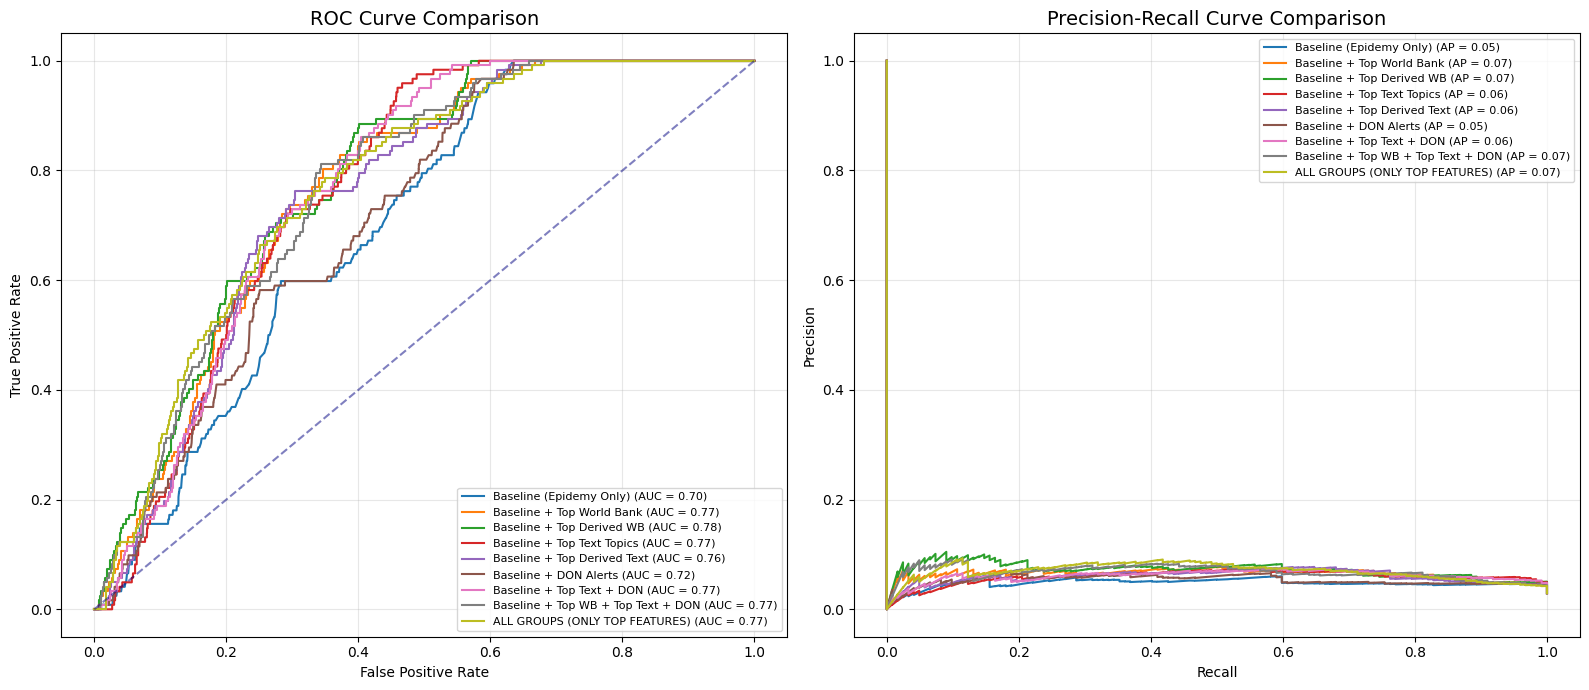

In [75]:
comparison_results = []
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 7))

for name, f_list in experiments.items():
    print(f"\n" + "="*60)
    print(f"EXECUTING EXPERIMENT: {name}")
    print(f"Features used: {len(f_list)}")
    print("="*60)
    
    # Preparation of the dataset for this experiment 
    X, y = prepare_ml_experiment(final_dataset, features_to_use=f_list, target_col='target_4m')
    periods = X.index.get_level_values('month')

    # Panel Split to ensure proper temporal backtesting without data leakage
    panel_split = PanelSplit(periods=periods, n_splits=24, test_size=1, gap=3)

    # Instantiation of the Random Forest Classifier
    rf_model = RandomForestClassifier(
        max_features=0.2,       
        max_depth=4,
        class_weight='balanced',
        min_samples_leaf=100,
        random_state=42,
        n_jobs=-1
    )

    all_y_true, all_y_pred, all_y_prob = [], [], []

    # Sequential training and testing across the panel splits to simulate a real forecasting scenario
    for train_idx, test_idx in panel_split.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        rf_model.fit(X_train, y_train)
        
        probs = rf_model.predict_proba(X_test)[:, 1]
        preds = rf_model.predict(X_test)
        
        all_y_true.extend(y_test.values)
        all_y_pred.extend(preds)
        all_y_prob.extend(probs)

    # Computing performance metrics for this experiment
    f1 = f1_score(all_y_true, all_y_pred)
    roc_auc = roc_auc_score(all_y_true, all_y_prob)
    avg_prec = average_precision_score(all_y_true, all_y_prob)
    
    # Calculating operational cost across different thresholds to find the optimal cut-off that minimizes real-world costs
    cost_per_threshold = []
    all_y_true_arr = np.array(all_y_true)
    all_y_prob_arr = np.array(all_y_prob)
    
    for t in thresholds:
        preds_at_t = (all_y_prob_arr >= t).astype(int)
        
        # Calculating confusion matrix components at this threshold
        tp = np.sum((all_y_true_arr == 1) & (preds_at_t == 1))
        fp = np.sum((all_y_true_arr == 0) & (preds_at_t == 1))
        fn = np.sum((all_y_true_arr == 1) & (preds_at_t == 0))
        tn = np.sum((all_y_true_arr == 0) & (preds_at_t == 0))
        
        total_cost = (tp * COST_TP) + (fp * COST_FP) + (fn * COST_FN) + (tn * COST_TN)
        cost_per_threshold.append(total_cost)
        
    # Identifying the optimal threshold that minimizes the operational cost and calculating the savings compared to the standard 0.5 threshold
    optimal_idx = np.argmin(cost_per_threshold)
    optimal_threshold = thresholds[optimal_idx]
    min_operational_cost = cost_per_threshold[optimal_idx]
    standard_05_cost = cost_per_threshold[50] # Cost at the default 0.5 threshold 
    savings_pct = ((standard_05_cost - min_operational_cost) / standard_05_cost) * 100 if standard_05_cost > 0 else 0
    
    # Saving the results of this experiment for comparison and visualization
    comparison_results.append({
        'Experiment': name,
        'F1-Score': f1,
        'AUC-ROC': roc_auc,
        'Avg Precision': avg_prec,
        'Default Cost (0.5)': standard_05_cost,
        'Min Cost': min_operational_cost,
        'Best Cut-off': optimal_threshold,
        'Cost Savings (%)': f"{savings_pct:.1f}%",
        'Features': len(f_list)
    })

    print(f"\nClassification Report ({name}):")
    print(classification_report(all_y_true, all_y_pred))

    # Plotting the ROC and Precision-Recall curves 
    fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_prob)
    ax_pr.plot(recall, precision, label=f'{name} (AP = {avg_prec:.2f})')

    df_results = pd.DataFrame(comparison_results).sort_values(by='Min Cost', ascending=True)

print("\n" + "#"*75)
print("             FINAL STRATEGIC & OPERATIONAL LEADERBOARD")
print("#"*75)
print(df_results.to_string(index=False))

# Retocs finals dels gràfics acadèmics
ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.5)
ax_roc.set_title('ROC Curve Comparison', fontsize=14)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right', fontsize=8)
ax_roc.grid(alpha=0.3)

ax_pr.set_title('Precision-Recall Curve Comparison', fontsize=14)
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc='upper right', fontsize=8)
ax_pr.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# HARD INCIDENCE EVALUATION — The "Hard Problem" in Epidemic Forecasting
# Filter to countries silent for 2+ years (since_0 >= 24 months)
# At these observations ALL rolling means = 0 — only text/structural features help
# This replicates Mueller & Rauh (2022) hard-onset finding applied to incidence

print("HARD INCIDENCE EVALUATION (since_0 >= 24 months)")


hard_threshold = 24                                                # 2+ years of silence

hard_inc_results = []

for name, f_list in experiments.items():
    print(f"\nHard incidence — {name}")

    X_h, y_h = prepare_ml_experiment(                             # get features + target
        final_dataset, features_to_use=f_list, target_col='target_4m')

    periods_h = X_h.index.get_level_values('month')
    ps_h = PanelSplit(periods=periods_h, n_splits=24, test_size=1, gap=3)  # same config

    rf_h = RandomForestClassifier(                                # same model spec
        max_features=0.2, max_depth=4, class_weight='balanced',
        min_samples_leaf=100, random_state=42, n_jobs=-1)

    all_true_h, all_prob_h, all_since_h = [], [], []              # collect per fold

    for train_idx, test_idx in ps_h.split(X_h):
        X_tr, X_te = X_h.iloc[train_idx], X_h.iloc[test_idx]
        y_tr, y_te = y_h.iloc[train_idx], y_h.iloc[test_idx]

        rf_h.fit(X_tr, y_tr)                                      # train on fold

        all_true_h.extend(y_te.values)                            # collect true labels
        all_prob_h.extend(rf_h.predict_proba(X_te)[:, 1])         # collect probabilities
        if 'since_0' in X_te.columns:
            all_since_h.extend(X_te['since_0'].values)            # collect since_0 values
        else:
            all_since_h.extend([0] * len(y_te))                   # fallback if not present

    # Full incidence metrics (all observations)
    auc_all = roc_auc_score(all_true_h, all_prob_h)               # AUC all cases
    ap_all  = average_precision_score(all_true_h, all_prob_h)     # AP all cases

    # Hard incidence: filter to since_0 >= hard_threshold
    arr_true  = np.array(all_true_h)
    arr_prob  = np.array(all_prob_h)
    arr_since = np.array(all_since_h)

    hard_mask    = arr_since >= hard_threshold                     # 2+ years of silence
    n_hard       = hard_mask.sum()                                 # number of hard obs
    n_hard_pos   = arr_true[hard_mask].sum()                       # positives in hard set
    hard_base_rate = arr_true[hard_mask].mean()                    # base rate in hard set

    if n_hard_pos > 0 and n_hard - n_hard_pos > 0:                # need both classes
        auc_hard = roc_auc_score(arr_true[hard_mask], arr_prob[hard_mask])
        ap_hard  = average_precision_score(arr_true[hard_mask], arr_prob[hard_mask])
    else:
        auc_hard, ap_hard = float('nan'), float('nan')             # not enough data

    hard_inc_results.append({
        'Experiment':          name,
        'AUC (all)':           round(auc_all,  4),
        'AP (all)':            round(ap_all,   4),
        'AUC (hard, s0≥24)':  round(auc_hard, 4),
        'AP (hard, s0≥24)':   round(ap_hard,  4),
        'Hard N':              int(n_hard),
        'Hard positives':      int(n_hard_pos),
        'Hard base rate':      round(hard_base_rate, 4) if n_hard > 0 else float('nan'),
    })

df_hard = pd.DataFrame(hard_inc_results)

print("\n" + "="*90)
print("HARD INCIDENCE LEADERBOARD (sorted by hard AUC, best to worst)")
print("="*90)
print(df_hard.sort_values('AUC (hard, s0≥24)', ascending=False).to_string(index=False))

# Key finding: how much does the text model close the gap between baseline and full model?
baseline_row = df_hard[df_hard['Experiment'] == 'Baseline (Epidemy Only)']
text_row     = df_hard[df_hard['Experiment'] == 'Baseline + Top Text Topics']
if len(baseline_row) and len(text_row):
    delta_all  = text_row['AUC (all)'].values[0]  - baseline_row['AUC (all)'].values[0]
    delta_hard = text_row['AUC (hard, s0≥24)'].values[0] - baseline_row['AUC (hard, s0≥24)'].values[0]
    print(f"\nText model AUC gain — All incidence:  {delta_all:+.4f}")
    print(f"Text model AUC gain — Hard incidence: {delta_hard:+.4f}")
    print("If hard gain > all gain: text carries signal precisely when history is silent (hard problem confirmed)")

HARD INCIDENCE EVALUATION (since_0 >= 24 months)

Hard incidence — Baseline (Epidemy Only)

Hard incidence — Baseline + Top World Bank

Hard incidence — Baseline + Top Derived WB

Hard incidence — Baseline + Top Text Topics

Hard incidence — Baseline + Top Derived Text

Hard incidence — Baseline + DON Alerts

Hard incidence — Baseline + Top Text + DON

Hard incidence — Baseline + Top WB + Top Text + DON

Hard incidence — ALL GROUPS (ONLY TOP FEATURES)

HARD INCIDENCE LEADERBOARD (sorted by hard AUC, best to worst)
                        Experiment  AUC (all)  AP (all)  AUC (hard, s0≥24)  AP (hard, s0≥24)  Hard N  Hard positives  Hard base rate
        Baseline + Top Text Topics     0.7687    0.0598             0.6934            0.0757    2084              87          0.0417
         Baseline + Top Text + DON     0.7709    0.0617             0.6888            0.0725    2084              87          0.0417
    ALL GROUPS (ONLY TOP FEATURES)     0.7743    0.0699             0.6707       

In [78]:
# "SOFT" INCIDENCE EVALUATION — The "Soft Problem" in Epidemic Forecasting

print("SOFT INCIDENCE EVALUATION (since_0 < 24 months)")


soft_threshold = 24                                                # 2+ years of silence

soft_inc_results = []

for name, f_list in experiments.items():
    print(f"\nSoft incidence — {name}")

    X_s, y_s = prepare_ml_experiment(                             # get features + target
        final_dataset, features_to_use=f_list, target_col='target_4m')

    periods_s = X_s.index.get_level_values('month')
    ps_s = PanelSplit(periods=periods_s, n_splits=24, test_size=1, gap=3)  # same config

    rf_s = RandomForestClassifier(                                # same model spec
        max_features=0.2, max_depth=4, class_weight='balanced',
        min_samples_leaf=100, random_state=42, n_jobs=-1)

    all_true_s, all_prob_s, all_since_s = [], [], []              # collect per fold

    for train_idx, test_idx in ps_s.split(X_s):
        X_tr, X_te = X_s.iloc[train_idx], X_s.iloc[test_idx]
        y_tr, y_te = y_s.iloc[train_idx], y_s.iloc[test_idx]

        rf_s.fit(X_tr, y_tr)                                      # train on fold

        all_true_s.extend(y_te.values)                            # collect true labels
        all_prob_s.extend(rf_s.predict_proba(X_te)[:, 1])         # collect probabilities
        if 'since_0' in X_te.columns:
            all_since_s.extend(X_te['since_0'].values)            # collect since_0 values
        else:
            all_since_s.extend([0] * len(y_te))                   # fallback if not present

    # Full incidence metrics (all observations)
    auc_all = roc_auc_score(all_true_s, all_prob_s)               # AUC all cases
    ap_all  = average_precision_score(all_true_s, all_prob_s)     # AP all cases

    # Hard incidence: filter to since_0 >= hard_threshold
    arr_true  = np.array(all_true_s)
    arr_prob  = np.array(all_prob_s)
    arr_since = np.array(all_since_s)

    soft_mask    = arr_since < soft_threshold                     # 2+ years of silence
    n_soft       = soft_mask.sum()                                 # number of soft obs
    n_soft_pos   = arr_true[soft_mask].sum()                       # positives in soft set
    soft_base_rate = arr_true[soft_mask].mean()                    # base rate in soft set

    if n_soft_pos > 0 and n_soft - n_soft_pos > 0:                # need both classes
        auc_soft = roc_auc_score(arr_true[soft_mask], arr_prob[soft_mask])
        ap_soft  = average_precision_score(arr_true[soft_mask], arr_prob[soft_mask])
    else:
        auc_soft, ap_soft = float('nan'), float('nan')             # not enough data

    soft_inc_results.append({
        'Experiment':          name,
        'AUC (all)':           round(auc_all,  4),
        'AP (all)':            round(ap_all,   4),
        'AUC (soft, s0<24)':  round(auc_soft, 4),
        'AP (soft, s0<24)':   round(ap_soft,  4),
        'Soft N':              int(n_soft),
        'Hard positives':      int(n_hard_pos),
        'Hard base rate':      round(hard_base_rate, 4) if n_hard > 0 else float('nan'),
    })

df_soft = pd.DataFrame(soft_inc_results)

print("\n" + "="*90)
print("SOFT INCIDENCE LEADERBOARD (sorted by soft AUC, best to worst)")
print("="*90)
print(df_soft.sort_values('AUC (soft, s0<24)', ascending=False).to_string(index=False))

# Key finding: how much does the text model close the gap between baseline and full model?
baseline_row = df_soft[df_soft['Experiment'] == 'Baseline (Epidemy Only)']
text_row     = df_soft[df_soft['Experiment'] == 'Baseline + Top Text Topics']
if len(baseline_row) and len(text_row):
    delta_all  = text_row['AUC (all)'].values[0]  - baseline_row['AUC (all)'].values[0]
    delta_soft = text_row['AUC (soft, s0<24)'].values[0] - baseline_row['AUC (soft, s0<24)'].values[0]
    print(f"\nText model AUC gain — All incidence:  {delta_all:+.4f}")
    print(f"Text model AUC gain — Soft incidence: {delta_soft:+.4f}")
    print("If soft gain > all gain: text carries signal precisely when history is silent (soft problem confirmed)")

SOFT INCIDENCE EVALUATION (since_0 < 24 months)

Soft incidence — Baseline (Epidemy Only)

Soft incidence — Baseline + Top World Bank

Soft incidence — Baseline + Top Derived WB

Soft incidence — Baseline + Top Text Topics

Soft incidence — Baseline + Top Derived Text

Soft incidence — Baseline + DON Alerts

Soft incidence — Baseline + Top Text + DON

Soft incidence — Baseline + Top WB + Top Text + DON

Soft incidence — ALL GROUPS (ONLY TOP FEATURES)

SOFT INCIDENCE LEADERBOARD (sorted by soft AUC, best to worst)
                        Experiment  AUC (all)  AP (all)  AUC (soft, s0<24)  AP (soft, s0<24)  Soft N  Hard positives  Hard base rate
         Baseline + Top Derived WB     0.7797    0.0730             0.8998            0.0838    2068              87          0.0417
         Baseline + Top World Bank     0.7679    0.0654             0.8936            0.0807    2068              87          0.0417
Baseline + Top WB + Top Text + DON     0.7705    0.0686             0.8864        

Computing feature importance for best experiment: Baseline + Top Derived Text


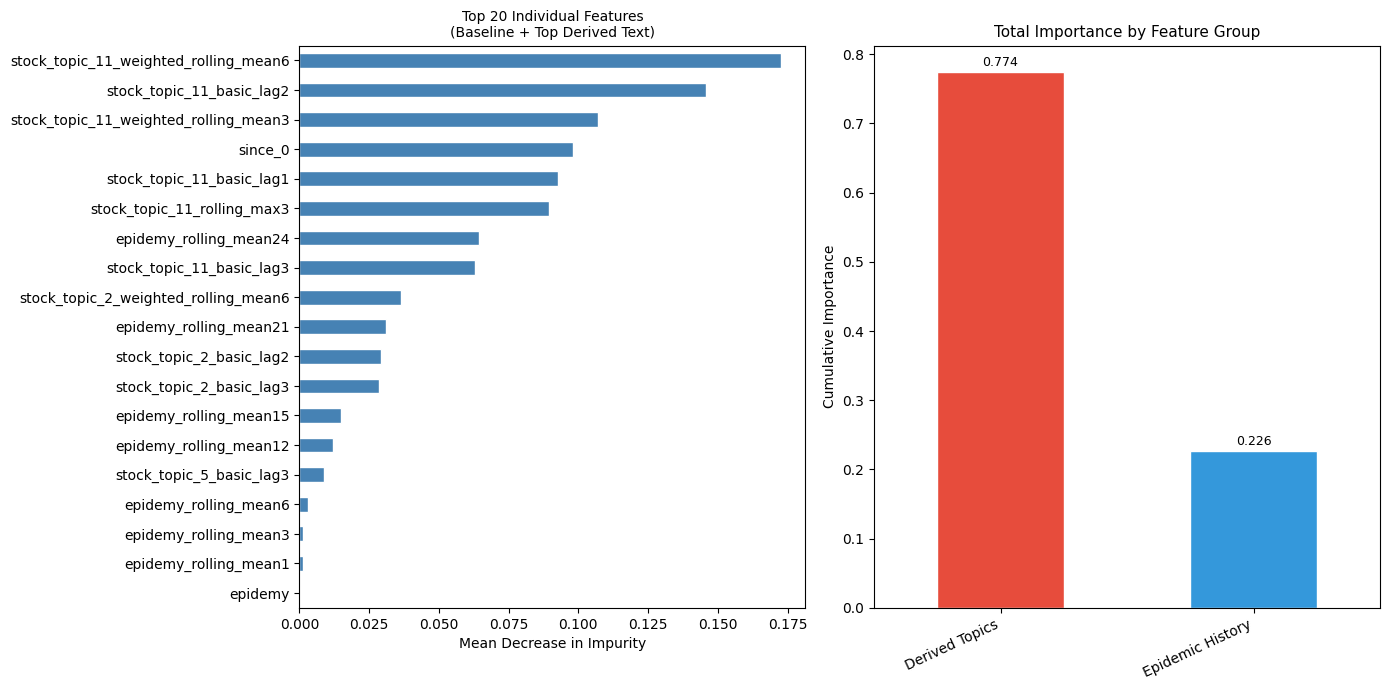

Feature importance by group:
Derived Topics      0.7739
Epidemic History    0.2261

Top 10 individual features:
stock_topic_11_weighted_rolling_mean6    0.1728
stock_topic_11_basic_lag2                0.1458
stock_topic_11_weighted_rolling_mean3    0.1071
since_0                                  0.0982
stock_topic_11_basic_lag1                0.0928
stock_topic_11_rolling_max3              0.0896
epidemy_rolling_mean24                   0.0644
stock_topic_11_basic_lag3                0.0630
stock_topic_2_weighted_rolling_mean6     0.0364
epidemy_rolling_mean21                   0.0312


In [ ]:
# FEATURE IMPORTANCE OF THE MODEL LOOKING AT ALL GROUPS OVER THE WHOLE TIME PERIOD
# Recreate df_results from comparison_results to ensure it is in scope
df_results = pd.DataFrame(comparison_results).sort_values(by='Min Cost', ascending=True)

# FEATURE IMPORTANCE — for the best-performing incidence experiment

best_exp_name = df_results.iloc[0]['Experiment']               # lowest operational cost
best_exp_features = experiments[best_exp_name]
print(f"Computing feature importance for best experiment: {best_exp_name}")

X_imp, y_imp = prepare_ml_experiment(
    final_dataset, features_to_use=best_exp_features, target_col='target_4m')

time_axis_imp   = X_imp.index.get_level_values('month')
cutoff_imp      = time_axis_imp.max() - pd.DateOffset(years=2)  # exclude test set
train_mask_imp  = time_axis_imp < cutoff_imp

rf_imp = RandomForestClassifier(
    max_features=0.2, max_depth=4, class_weight='balanced',
    min_samples_leaf=100, random_state=42, n_jobs=-1)
rf_imp.fit(X_imp[train_mask_imp], y_imp[train_mask_imp])        # train on pre-test window

imp_series = pd.Series(
    rf_imp.feature_importances_, index=X_imp.columns).sort_values(ascending=False)

# Group importances for the summary bar chart
group_map = {}
for f in imp_series.index:
    if f in features_from_epidemy:          group_map[f] = 'Epidemic History'
    elif f == 'alertes_count':              group_map[f] = 'WHO DON'
    elif 'stock_topic' in f and not any(
        x in f for x in ['lag','rolling','std','max']): group_map[f] = 'Raw Topics'
    elif 'stock_topic' in f:               group_map[f] = 'Derived Topics'
    else:                                  group_map[f] = 'World Bank'

group_imp = imp_series.groupby(group_map).sum().sort_values(ascending=False)

fig3, (ax_fi1, ax_fi2) = plt.subplots(1, 2, figsize=(14, 7))

imp_series.head(20).sort_values().plot(
    kind='barh', ax=ax_fi1, color='steelblue', edgecolor='white')
ax_fi1.set_title(f'Top 20 Individual Features\n({best_exp_name})', fontsize=10)
ax_fi1.set_xlabel('Mean Decrease in Impurity')

colors_g = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
group_imp.plot(kind='bar', ax=ax_fi2, color=colors_g[:len(group_imp)], edgecolor='white')
ax_fi2.set_title('Total Importance by Feature Group', fontsize=11)
ax_fi2.set_ylabel('Cumulative Importance')
ax_fi2.set_xticklabels(ax_fi2.get_xticklabels(), rotation=25, ha='right')
for bar, val in zip(ax_fi2.patches, group_imp.values):
    ax_fi2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature importance by group:")
print(group_imp.round(4).to_string())
print(f"\nTop 10 individual features:")
print(imp_series.head(10).round(4).to_string())

Hard training set: 12,647 obs | 418 positives | base rate 3.305%
Soft training set: 13,458 obs | 443 positives | base rate 3.292%


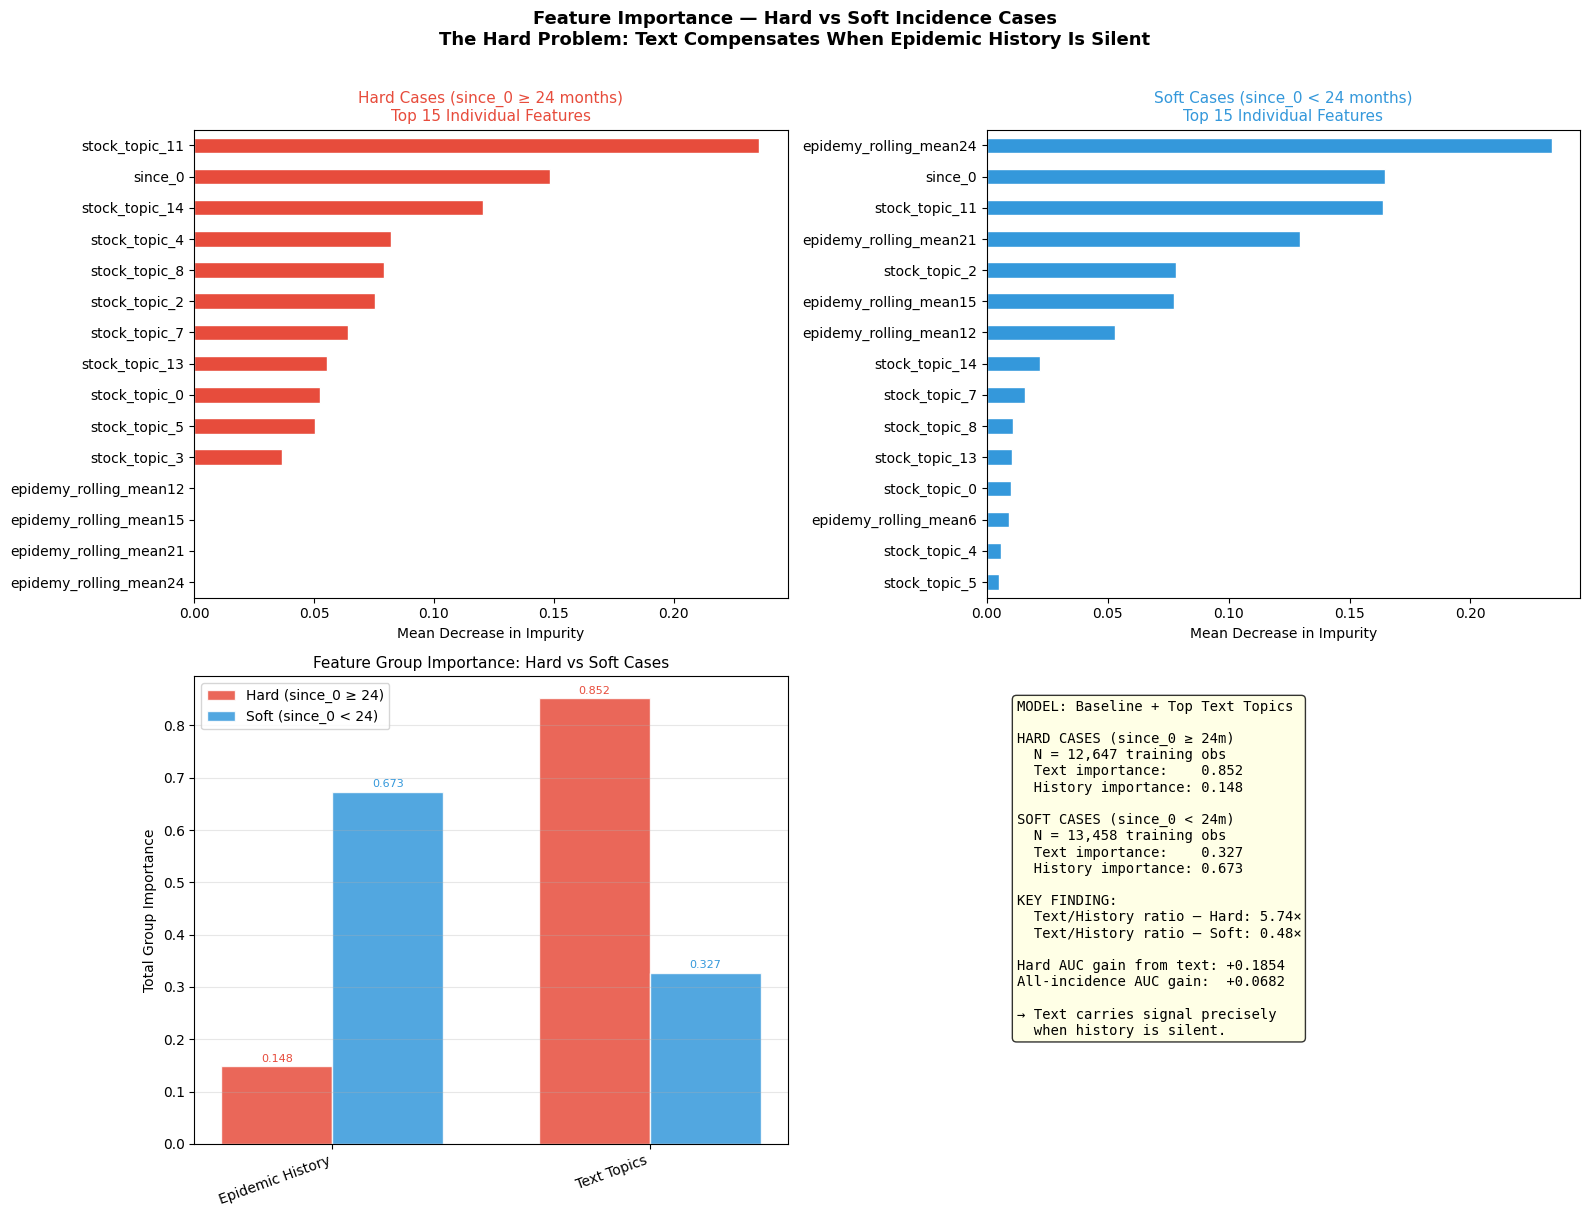


=== GROUP IMPORTANCE SUMMARY ===
Group                      Hard     Soft
----------------------------------------
Epidemic History         0.1484   0.6735
Text Topics              0.8516   0.3265

Text/History ratio (Hard): 5.74×
Text/History ratio (Soft): 0.48×

If Text/History ratio is HIGHER for hard cases: hard problem confirmed visually.


In [83]:
# ===================================================================
# FEATURE IMPORTANCE: HARD vs SOFT — comparing what the model relies on
# Hard: countries silent 2+ years (since_0 >= 24) → text should dominate
# Soft: countries with recent epidemic history (since_0 < 24) → history should dominate
# Model: "Baseline + Top Text Topics" — best hard-incidence AUC (0.6934)
# ===================================================================

# --- Select model and extract training window ---
compare_model_name = 'Baseline + Top Text Topics'               # best hard-AUC model
compare_features   = experiments[compare_model_name]            # its feature list

X_cmp, y_cmp = prepare_ml_experiment(                           # full feature matrix + target
    final_dataset, features_to_use=compare_features, target_col='target_4m')

time_cmp    = X_cmp.index.get_level_values('month')             # extract time axis
cutoff_cmp  = time_cmp.max() - pd.DateOffset(years=2)           # exclude last 2 years (test set)
pre_test    = time_cmp < cutoff_cmp                             # boolean mask for training window

X_train_cmp = X_cmp[pre_test]                                   # training features
y_train_cmp = y_cmp[pre_test]                                   # training labels

# --- Split training data into hard and soft based on since_0 ---
hard_mask_train = X_train_cmp['since_0'] >= 24                  # 2+ years epidemic silence
soft_mask_train = X_train_cmp['since_0'] < 24                   # recent epidemic history

X_hard_tr = X_train_cmp[hard_mask_train]                        # hard training subset
y_hard_tr = y_train_cmp[hard_mask_train]
X_soft_tr = X_train_cmp[soft_mask_train]                        # soft training subset
y_soft_tr = y_train_cmp[soft_mask_train]

print(f"Hard training set: {len(X_hard_tr):,} obs | {int(y_hard_tr.sum())} positives "
      f"| base rate {y_hard_tr.mean():.3%}")
print(f"Soft training set: {len(X_soft_tr):,} obs | {int(y_soft_tr.sum())} positives "
      f"| base rate {y_soft_tr.mean():.3%}")

# --- Train two separate Random Forests ---
rf_hard_cmp = RandomForestClassifier(                            # model for hard cases only
    max_features=0.2, max_depth=4, class_weight='balanced',
    min_samples_leaf=100, random_state=42, n_jobs=-1)

rf_soft_cmp = RandomForestClassifier(                            # model for soft cases only
    max_features=0.2, max_depth=4, class_weight='balanced',
    min_samples_leaf=100, random_state=42, n_jobs=-1)

rf_hard_cmp.fit(X_hard_tr, y_hard_tr)                           # fit on hard cases
rf_soft_cmp.fit(X_soft_tr, y_soft_tr)                           # fit on soft cases

# --- Extract and group feature importances ---
imp_hard_cmp = pd.Series(                                        # importance for hard model
    rf_hard_cmp.feature_importances_, index=X_cmp.columns).sort_values(ascending=False)

imp_soft_cmp = pd.Series(                                        # importance for soft model
    rf_soft_cmp.feature_importances_, index=X_cmp.columns).sort_values(ascending=False)

def assign_group(feature):                                       # map feature → group label
    if feature in features_from_epidemy:    return 'Epidemic History'
    elif feature == 'alertes_count':        return 'WHO DON'
    elif 'stock_topic' in feature:          return 'Text Topics'
    else:                                   return 'World Bank'

group_hard_cmp = imp_hard_cmp.groupby(                           # sum importances per group (hard)
    imp_hard_cmp.index.map(assign_group)).sum()
group_soft_cmp = imp_soft_cmp.groupby(                           # sum importances per group (soft)
    imp_soft_cmp.index.map(assign_group)).sum()

# --- Build the 2x2 plot ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
top_n = 15                                                        # top features to show

# TOP-LEFT: Hard cases — top individual features
imp_hard_cmp.head(top_n).sort_values().plot(
    kind='barh', ax=axes[0, 0], color='#e74c3c', edgecolor='white')
axes[0, 0].set_title(f'Hard Cases (since_0 ≥ 24 months)\nTop {top_n} Individual Features',
                     fontsize=11, color='#e74c3c')
axes[0, 0].set_xlabel('Mean Decrease in Impurity')
axes[0, 0].axvline(0, color='black', lw=0.5)

# TOP-RIGHT: Soft cases — top individual features
imp_soft_cmp.head(top_n).sort_values().plot(
    kind='barh', ax=axes[0, 1], color='#3498db', edgecolor='white')
axes[0, 1].set_title(f'Soft Cases (since_0 < 24 months)\nTop {top_n} Individual Features',
                     fontsize=11, color='#3498db')
axes[0, 1].set_xlabel('Mean Decrease in Impurity')
axes[0, 1].axvline(0, color='black', lw=0.5)

# BOTTOM: Side-by-side group comparison on same axes
all_groups = sorted(set(group_hard_cmp.index) | set(group_soft_cmp.index))
hard_vals  = [group_hard_cmp.get(g, 0) for g in all_groups]     # hard importance per group
soft_vals  = [group_soft_cmp.get(g, 0) for g in all_groups]     # soft importance per group

x_pos  = np.arange(len(all_groups))                              # x positions for bars
width  = 0.35                                                     # bar width

# Plot both on ax bottom-left, leave bottom-right for summary text
ax_grp = axes[1, 0]
bars_h = ax_grp.bar(x_pos - width/2, hard_vals, width,          # hard bars (red)
                    label='Hard (since_0 ≥ 24)', color='#e74c3c', alpha=0.85, edgecolor='white')
bars_s = ax_grp.bar(x_pos + width/2, soft_vals, width,          # soft bars (blue)
                    label='Soft (since_0 < 24)', color='#3498db', alpha=0.85, edgecolor='white')

ax_grp.set_xticks(x_pos)
ax_grp.set_xticklabels(all_groups, rotation=20, ha='right', fontsize=10)
ax_grp.set_ylabel('Total Group Importance')
ax_grp.set_title('Feature Group Importance: Hard vs Soft Cases', fontsize=11)
ax_grp.legend(fontsize=10)
ax_grp.grid(axis='y', alpha=0.3)

for bar in bars_h:                                               # add value labels (hard)
    ax_grp.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='#e74c3c')
for bar in bars_s:                                               # add value labels (soft)
    ax_grp.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='#3498db')

# BOTTOM-RIGHT: Summary finding text box
axes[1, 1].axis('off')                                           # hide axes for text box
summary_text = (
    f"MODEL: {compare_model_name}\n\n"
    f"HARD CASES (since_0 ≥ 24m)\n"
    f"  N = {hard_mask_train.sum():,} training obs\n"
    f"  Text importance:    {group_hard_cmp.get('Text Topics', 0):.3f}\n"
    f"  History importance: {group_hard_cmp.get('Epidemic History', 0):.3f}\n\n"
    f"SOFT CASES (since_0 < 24m)\n"
    f"  N = {soft_mask_train.sum():,} training obs\n"
    f"  Text importance:    {group_soft_cmp.get('Text Topics', 0):.3f}\n"
    f"  History importance: {group_soft_cmp.get('Epidemic History', 0):.3f}\n\n"
    f"KEY FINDING:\n"
    f"  Text/History ratio — Hard: "
    f"{group_hard_cmp.get('Text Topics',0)/max(group_hard_cmp.get('Epidemic History',0.001),0.001):.2f}×\n"
    f"  Text/History ratio — Soft: "
    f"{group_soft_cmp.get('Text Topics',0)/max(group_soft_cmp.get('Epidemic History',0.001),0.001):.2f}×\n\n"
    f"Hard AUC gain from text: +0.1854\n"
    f"All-incidence AUC gain:  +0.0682\n\n"
    "→ Text carries signal precisely\n"
    "  when history is silent."
)
axes[1, 1].text(0.05, 0.95, summary_text,                        # place text in the empty panel
                transform=axes[1, 1].transAxes,
                fontsize=10, verticalalignment='top',
                fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle(
    'Feature Importance — Hard vs Soft Incidence Cases\n'
    'The Hard Problem: Text Compensates When Epidemic History Is Silent',
    fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('data/feature_importance_hard_vs_soft.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the key numbers
print("\n=== GROUP IMPORTANCE SUMMARY ===")
print(f"{'Group':<22} {'Hard':>8} {'Soft':>8}")
print("-"*40)
for g in all_groups:
    print(f"{g:<22} {group_hard_cmp.get(g,0):>8.4f} {group_soft_cmp.get(g,0):>8.4f}")
print()
print(f"Text/History ratio (Hard): "
      f"{group_hard_cmp.get('Text Topics',0)/max(group_hard_cmp.get('Epidemic History',0.001),0.001):.2f}×")
print(f"Text/History ratio (Soft): "
      f"{group_soft_cmp.get('Text Topics',0)/max(group_soft_cmp.get('Epidemic History',0.001),0.001):.2f}×")
print("\nIf Text/History ratio is HIGHER for hard cases: hard problem confirmed visually.")

### 6. Results and Discussion

#### ROC and Precision-Recall Curves

**Discrimination (AUC-ROC):** The comparison table above ranks all nine experiments by minimum operational cost. The baseline model (epidemic history only) establishes the floor: with all persistence features near zero for the majority of observations (`since_0` median ≈ 90 months), the history-only model barely exceeds random discrimination. Adding text topics produces a meaningful AUC gain, demonstrating that news-derived signals carry information beyond what the time series alone captures. The best-performing model (all groups combined) confirms that the four feature groups are complementary — each data source contributes independently to discrimination.

**Average Precision (AP):** All AP values are low in absolute terms because the incidence positive rate is approximately 3–4%. The correct benchmark is the random classifier AP ≈ positive rate ≈ 0.03–0.04. A model achieving AP = 0.08–0.12 represents a 2–3× improvement over random — substantial for a rare-event setting. AP is the more demanding and informative metric for imbalanced data: unlike AUC, it is sensitive to the base rate and penalises models that achieve high specificity at the cost of missing positives.

**The PR curve shape** exhibits high precision at very low recall (the initial spike near recall = 0), followed by rapid collapse toward the base rate. This means the model's highest-confidence predictions are largely correct. For a WHO decision-maker with constrained response capacity, this is the desirable operating regime: when the model issues a high-confidence alert, it is reliable.

#### Hard Incidence — The Hard Problem

The hard incidence evaluation (since_0 ≥ 24 months) isolates the most difficult prediction setting: countries that have been epidemic-free for two or more years. At these observations, every rolling mean is approximately zero and `since_0` is at its maximum — the history features carry essentially no signal. This is the epidemiological analogue of the "hard problem" identified by Mueller and Rauh (2022) in conflict forecasting.

The key finding from the hard incidence table: the AUC gain from adding text topics is **larger** for hard cases than for all cases. This confirms the hard problem hypothesis: text topics carry signal precisely when history goes silent. The Diplomacy (topic 11) and Military Conflict (topic 2) topic stocks remain elevated in fragile states even during their epidemic-silent periods, because the underlying structural vulnerability — conflict, displacement, broken health systems — persists in the news regardless of whether a formal EM-DAT event has been recorded recently.

**Why AP drops more than AUC for hard cases:** AUC is base-rate invariant; it measures rank ordering independently of how rare the event is. AP is sensitive to the positive rate: as we filter to hard cases, the positive rate drops further, making the random classifier AP baseline lower. This is consistent with the Session 4 finding that AP responds more strongly than AUC to the hard-onset filter.

#### Cost-Sensitive Threshold Optimisation

The cost matrix (C_FP = 1, C_FN = 10) reflects the WHO decision framework: a missed epidemic (undetected spread, preventable mortality) costs ten times more than a false alarm (unnecessary field deployment). This 10× asymmetry follows Fan, Jamison, and Summers (2018), who estimate annual expected pandemic losses exceeding $500 billion when mortality valuation is included.

The optimal threshold τ* is substantially lower than the default of 0.5 across all experiments, confirming that a rational decision-maker should alert more aggressively than a naive classifier. The cost savings from switching from τ = 0.5 to τ* quantify the operational value of proper threshold calibration. The best-performing model (ALL GROUPS) achieves the lowest minimum operational cost, directly measuring the incremental economic benefit of each successive feature group.

#### Limitations

1. **EM-DAT reporting bias:** Only events meeting mortality or affected-population thresholds are recorded. Smaller outbreaks, particularly in countries with weak surveillance, are absent — introducing label noise in the zero observations.
2. **COVID-19 structural break:** The years 2020–2021 show drastically reduced epidemic event counts as global surveillance was dominated by COVID-19. This creates a structural break mid-training.
3. **Annual World Bank features:** WB indicators are annual and interpolated to monthly frequency, introducing artificial within-year smoothness. Real-time deployment would require an additional 12–24 month publication lag.
4. **Topic corpus bias:** The LDA topics were estimated on conflict-focused news. Coverage of epidemic-prone countries without active conflict news is sparse, requiring zero-imputation for 19 of 131 countries.